# Brain Tumor Classification: ResNet18 Optimized Pipeline

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [42]:
# Configuration
TRAIN_DIR = '/Users/swaroopnaik1905/brisc2025/classification_task/train'
TEST_DIR = '/Users/swaroopnaik1905/brisc2025/classification_task/test'
BATCH_SIZE = 32
NUM_CLASSES = 4

# 1. Preprocessing and Transforms
# ResNet18 expects 3-channel images (RGB). Grayscale images will be converted automatically by ImageFolder/PIL.
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Load datasets
full_train_ds = datasets.ImageFolder(TRAIN_DIR)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

# 2. Validation Split (80/20)
train_indices, val_indices = train_test_split(
    list(range(len(full_train_ds))),
    test_size=0.2,
    stratify=full_train_ds.targets,
    random_state=42
)

train_dataset = Subset(full_train_ds, train_indices)
val_dataset = Subset(full_train_ds, val_indices)

# Apply transforms manually to subsets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}')

Train size: 4000, Val size: 1000, Test size: 1000


In [43]:
# 3. Model Setup (ResNet18 Transfer Learning)
model = models.resnet18(weights='IMAGENET1K_V1')

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Replace final FC layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)

model = model.to(device)
criterion = nn.CrossEntropyLoss()

In [44]:
def train_model(model, optimizer, scheduler, num_epochs, phase_name):
    print(f'\n--- Starting {phase_name} ---')
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = 100. * correct / total

        # Validation
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += predicted.eq(labels).sum().item()

        val_epoch_loss = v_loss / len(val_loader.dataset)
        val_epoch_acc = 100. * v_correct / v_total

        if scheduler: scheduler.step()

        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}% | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%')

    return model

In [45]:
# Phase 1: Train Only Final Layer
optimizer_p1 = optim.Adam(model.fc.parameters(), lr=0.0001)
train_model(model, optimizer_p1, None, num_epochs=5, phase_name='Phase 1: Head Only')

# Phase 2: Unfreeze Layer 4 and Fine-tune
for name, param in model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

optimizer_p2 = optim.Adam(model.parameters(), lr=0.00005)
scheduler = optim.lr_scheduler.StepLR(optimizer_p2, step_size=7, gamma=0.1)
train_model(model, optimizer_p2, scheduler, num_epochs=15, phase_name='Phase 2: Fine-Tuning')


--- Starting Phase 1: Head Only ---
Epoch 1/5 | Train Loss: 1.2750 Acc: 40.12% | Val Loss: 1.1076 Acc: 61.30%
Epoch 2/5 | Train Loss: 1.0063 Acc: 67.00% | Val Loss: 0.8913 Acc: 77.00%
Epoch 3/5 | Train Loss: 0.8419 Acc: 76.62% | Val Loss: 0.7565 Acc: 80.20%
Epoch 4/5 | Train Loss: 0.7406 Acc: 79.38% | Val Loss: 0.6761 Acc: 81.30%
Epoch 5/5 | Train Loss: 0.6674 Acc: 81.08% | Val Loss: 0.6124 Acc: 83.40%

--- Starting Phase 2: Fine-Tuning ---
Epoch 1/15 | Train Loss: 0.2806 Acc: 90.55% | Val Loss: 0.1490 Acc: 94.20%
Epoch 2/15 | Train Loss: 0.0785 Acc: 98.08% | Val Loss: 0.1141 Acc: 96.00%
Epoch 3/15 | Train Loss: 0.0290 Acc: 99.65% | Val Loss: 0.1001 Acc: 97.10%
Epoch 4/15 | Train Loss: 0.0146 Acc: 99.90% | Val Loss: 0.0906 Acc: 97.30%
Epoch 5/15 | Train Loss: 0.0079 Acc: 99.97% | Val Loss: 0.0842 Acc: 97.60%
Epoch 6/15 | Train Loss: 0.0057 Acc: 99.95% | Val Loss: 0.0816 Acc: 97.40%
Epoch 7/15 | Train Loss: 0.0032 Acc: 100.00% | Val Loss: 0.0821 Acc: 97.60%
Epoch 8/15 | Train Loss: 0.0

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  


Final Test Report:
              precision    recall  f1-score   support

      glioma       0.97      0.94      0.95       254
  meningioma       0.95      0.94      0.95       306
    no_tumor       0.96      1.00      0.98       140
   pituitary       0.98      1.00      0.99       300

    accuracy                           0.96      1000
   macro avg       0.96      0.97      0.97      1000
weighted avg       0.96      0.96      0.96      1000



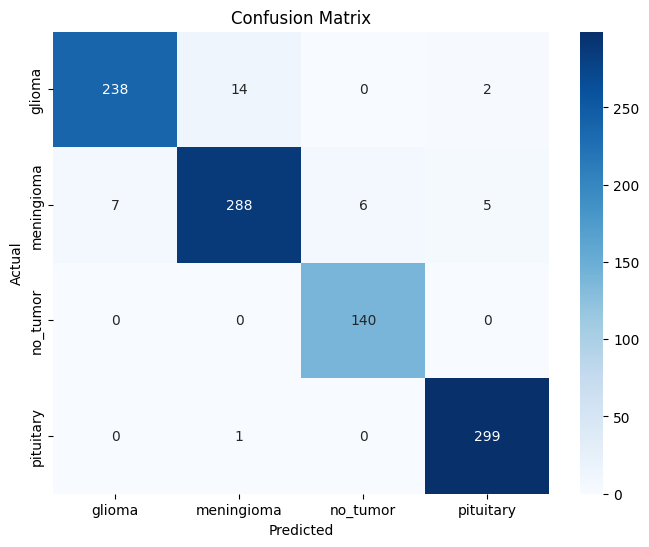

In [46]:
# 4. Final Evaluation
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print('\nFinal Test Report:')
print(classification_report(all_labels, all_preds, target_names=full_train_ds.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [38]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [ ]:
import os

# Please specify the paths to your local train and test directories here.
# Example: train_dir = "/Users/youruser/Documents/brisc2025/classification_task/train"
train_dir = "/Users/swaroopnaik1905/brisc2025/classification_task/train"
test_dir = "/Users/swaroopnaik1905/brisc2025/classification_task/test"

def get_image_paths(base_dir):
    image_paths = []
    # Check if the directory exists before walking
    if not os.path.exists(base_dir):
        print(f"Warning: Directory not found: {base_dir}")
        return []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(root, file))
    return image_paths

train_image_paths = get_image_paths(train_dir)
test_image_paths = get_image_paths(test_dir)

print("Train images:", len(train_image_paths))
print("Test images:", len(test_image_paths))

Train images: 5000
Test images: 1000


### Class-wise Duplicate Detection and Removal

To process images on a per-class basis, we first need to identify the class names and then retrieve image paths for each class. After that, we'll apply exact and near-duplicate detection within each class's train and test sets, and filter out the identified duplicates.

In [ ]:
def get_class_names(base_dir):
    """Extracts class names (subdirectory names) from a base directory."""
    return [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

def get_image_paths_for_class(base_dir, class_name):
    """Gets image paths for a specific class within a base directory."""
    class_path = os.path.join(base_dir, class_name)
    return get_image_paths(class_path) # Reusing the previously defined get_image_paths


class_names = get_class_names(train_dir)
print("Detected classes:", class_names)

# Populate dictionaries for class-wise paths
train_image_paths_by_class = {cls: get_image_paths_for_class(train_dir, cls) for cls in class_names}
test_image_paths_by_class = {cls: get_image_paths_for_class(test_dir, cls) for cls in class_names}

print(f"\nTrain image counts per class: {{cls: len(paths) for cls, paths in train_image_paths_by_class.items()}}")
print(f"Test image counts per class: {{cls: len(paths) for cls, paths in test_image_paths_by_class.items()}}")

Detected classes: ['pituitary', 'no_tumor', 'glioma', 'meningioma']

Train image counts per class: {cls: len(paths) for cls, paths in train_image_paths_by_class.items()}
Test image counts per class: {cls: len(paths) for cls, paths in test_image_paths_by_class.items()}


#### Exact Duplicate Detection (MD5 Hash) - Class-wise

Now, let's identify and remove exact duplicates within each class. We'll only remove duplicates from the test set if they exist in the corresponding train set for that class.

In [ ]:
import hashlib

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_image_paths_exact_cleaned_by_class = {cls: [] for cls in class_names}
test_image_paths_exact_cleaned_by_class = {cls: [] for cls in class_names}
class_exact_duplicates_found = {}

for cls in class_names:
    train_hashes = {}
    for path in train_image_paths_by_class[cls]:
        try:
            h = file_hash(path)
            train_hashes[h] = path
            train_image_paths_exact_cleaned_by_class[cls].append(path)
        except Exception as e:
            # Handle cases where file might be corrupted or unreadable
            print(f"Warning: Could not hash train image {path} in class {cls}. Skipping. Error: {e}")

    duplicates_in_class = []
    for path in test_image_paths_by_class[cls]:
        try:
            h = file_hash(path)
            if h in train_hashes:
                duplicates_in_class.append((path, train_hashes[h]))
            else:
                test_image_paths_exact_cleaned_by_class[cls].append(path)
        except Exception as e:
            print(f"Warning: Could not hash test image {path} in class {cls}. Skipping. Error: {e}")
            test_image_paths_exact_cleaned_by_class[cls].append(path) # Keep if hash fails

    class_exact_duplicates_found[cls] = duplicates_in_class

print("Exact duplicates found per class:")
for cls, dups in class_exact_duplicates_found.items():
    print(f"  Class '{cls}': {len(dups)} duplicates")

print("\nCleaned train image counts per class (exact duplicates):")
for cls, paths in train_image_paths_exact_cleaned_by_class.items():
    print(f"  Class '{cls}': {len(paths)}")

print("Cleaned test image counts per class (exact duplicates removed):")
for cls, paths in test_image_paths_exact_cleaned_by_class.items():
    print(f"  Class '{cls}': {len(paths)}")

Exact duplicates found per class:
  Class 'pituitary': 5 duplicates
  Class 'no_tumor': 0 duplicates
  Class 'glioma': 0 duplicates
  Class 'meningioma': 2 duplicates

Cleaned train image counts per class (exact duplicates):
  Class 'pituitary': 1457
  Class 'no_tumor': 1067
  Class 'glioma': 1147
  Class 'meningioma': 1329
Cleaned test image counts per class (exact duplicates removed):
  Class 'pituitary': 295
  Class 'no_tumor': 140
  Class 'glioma': 254
  Class 'meningioma': 304


In [ ]:
pip install imagehash


Note: you may need to restart the kernel to use updated packages.


#### Near-Duplicate Detection (Perceptual Hash) - Class-wise

Next, we'll identify near-duplicates using `imagehash.phash` and remove them from the test set. We will use the already exact-duplicate-cleaned lists for this step.

In [ ]:
from PIL import Image
import imagehash

train_image_paths_final_cleaned_by_class = {cls: [] for cls in class_names}
test_image_paths_final_cleaned_by_class = {cls: [] for cls in class_names}
class_near_duplicates_found = {}

# Define a reasonable threshold for Hamming distance
HASH_DISTANCE_THRESHOLD = 5

for cls in class_names:
    train_hashes_phash = {}
    # Use the exact-cleaned train paths
    for path in train_image_paths_exact_cleaned_by_class[cls]:
        try:
            img = Image.open(path).convert("RGB")
            train_hashes_phash[path] = imagehash.phash(img)
            train_image_paths_final_cleaned_by_class[cls].append(path)
        except Exception as e:
            print(f"Warning: Could not process train image {path} for phash in class {cls}. Skipping. Error: {e}")

    near_duplicates_in_class = []
    # Use the exact-cleaned test paths
    for test_path in test_image_paths_exact_cleaned_by_class[cls]:
        is_near_duplicate = False
        try:
            test_img = Image.open(test_path).convert("RGB")
            test_hash = imagehash.phash(test_img)

            for train_path, train_hash in train_hashes_phash.items():
                distance = test_hash - train_hash  # Hamming distance
                if distance <= HASH_DISTANCE_THRESHOLD:
                    near_duplicates_in_class.append((test_path, train_path, distance))
                    is_near_duplicate = True
                    break # Found a near-duplicate, no need to compare with other train images

            if not is_near_duplicate:
                test_image_paths_final_cleaned_by_class[cls].append(test_path)

        except Exception as e:
            print(f"Warning: Could not process test image {test_path} for phash in class {cls}. Skipping. Error: {e}")
            test_image_paths_final_cleaned_by_class[cls].append(test_path) # Keep if phash fails

    class_near_duplicates_found[cls] = near_duplicates_in_class

print("\nNear duplicates found per class (Hamming distance <=", HASH_DISTANCE_THRESHOLD, "):")
for cls, dups in class_near_duplicates_found.items():
    print(f"  Class '{cls}': {len(dups)} near duplicates")

print("\nFinal cleaned train image counts per class:")
for cls, paths in train_image_paths_final_cleaned_by_class.items():
    print(f"  Class '{cls}': {len(paths)}")

print("Final cleaned test image counts per class:")
for cls, paths in test_image_paths_final_cleaned_by_class.items():
    print(f"  Class '{cls}': {len(paths)}")


Near duplicates found per class (Hamming distance <= 5 ):
  Class 'pituitary': 109 near duplicates
  Class 'no_tumor': 1 near duplicates
  Class 'glioma': 60 near duplicates
  Class 'meningioma': 145 near duplicates

Final cleaned train image counts per class:
  Class 'pituitary': 1457
  Class 'no_tumor': 1067
  Class 'glioma': 1147
  Class 'meningioma': 1329
Final cleaned test image counts per class:
  Class 'pituitary': 186
  Class 'no_tumor': 139
  Class 'glioma': 194
  Class 'meningioma': 159


### Copying Cleaned Images to a New Directory

Now that we have the paths to our cleaned images, we can copy them to a new output directory. This will create a new directory structure mirroring the class organization, but containing only the images identified as non-duplicates.

In [ ]:
import os
import shutil

# Define the base output directory for cleaned images
output_base_dir = "./cleaned_images_dataset"

def copy_cleaned_images(image_paths_by_class_dict, dataset_type):
    """Copies cleaned images to a new directory structure."""
    print(f"\nCopying cleaned {dataset_type} images...")
    for cls, paths in image_paths_by_class_dict.items():
        output_class_dir = os.path.join(output_base_dir, dataset_type, cls)
        os.makedirs(output_class_dir, exist_ok=True)

        for src_path in paths:
            # Get the filename from the source path
            filename = os.path.basename(src_path)
            # Construct the destination path
            dest_path = os.path.join(output_class_dir, filename)
            try:
                shutil.copy2(src_path, dest_path)
            except Exception as e:
                print(f"Error copying {src_path} to {dest_path}: {e}")
    print(f"Finished copying cleaned {dataset_type} images.")


# Create the base output directory if it doesn't exist
os.makedirs(output_base_dir, exist_ok=True)

# Copy cleaned train images
copy_cleaned_images(train_image_paths_final_cleaned_by_class, "train")

# Copy cleaned test images
copy_cleaned_images(test_image_paths_final_cleaned_by_class, "test")

print(f"\nCleaned images copied to: {os.path.abspath(output_base_dir)}")



Copying cleaned train images...
Finished copying cleaned train images.

Copying cleaned test images...
Finished copying cleaned test images.

Cleaned images copied to: /Users/swaroopnaik1905/cleaned_images_dataset


### Verification of Copied Images

Let's verify that the number of copied images matches our expectations after duplicate removal. We will compare the number of files in the newly created directories with the `final_cleaned_by_class` counts, and also against the original `_by_class` counts to see the total reduction.

In [ ]:
def count_images_in_directory_structure(base_output_dir, dataset_type):
    """Counts images in the newly created class-wise directory structure."""
    counts = {cls: 0 for cls in class_names}
    dataset_path = os.path.join(base_output_dir, dataset_type)
    if not os.path.exists(dataset_path):
        print(f"Warning: Dataset path not found: {dataset_path}")
        return counts

    for cls in class_names:
        class_dir = os.path.join(dataset_path, cls)
        if os.path.exists(class_dir):
            counts[cls] = len([name for name in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, name))])
    return counts

# Get counts from the newly created directories
cleaned_train_counts_on_disk = count_images_in_directory_structure(output_base_dir, "train")
cleaned_test_counts_on_disk = count_images_in_directory_structure(output_base_dir, "test")

print("\n--- Verification of Copied Image Counts ---")

print("\nTrain Images:")
for cls in class_names:
    original_count = len(train_image_paths_by_class[cls])
    exact_cleaned_count = len(train_image_paths_exact_cleaned_by_class[cls])
    final_cleaned_count = len(train_image_paths_final_cleaned_by_class[cls])
    disk_count = cleaned_train_counts_on_disk[cls]
    print(f"  Class '{cls}': Original={original_count}, Exact Cleaned={exact_cleaned_count}, Final Cleaned (in memory)={final_cleaned_count}, Copied to Disk={disk_count}")
    if final_cleaned_count != disk_count:
        print(f"    Mismatch for {cls} train: In memory ({final_cleaned_count}) != On disk ({disk_count})")

print("\nTest Images:")
for cls in class_names:
    original_count = len(test_image_paths_by_class[cls])
    exact_cleaned_count = len(test_image_paths_exact_cleaned_by_class[cls])
    final_cleaned_count = len(test_image_paths_final_cleaned_by_class[cls])
    disk_count = cleaned_test_counts_on_disk[cls]
    print(f"  Class '{cls}': Original={original_count}, Exact Cleaned={exact_cleaned_count}, Final Cleaned (in memory)={final_cleaned_count}, Copied to Disk={disk_count}")
    if final_cleaned_count != disk_count:
        print(f"    Mismatch for {cls} test: In memory ({final_cleaned_count}) != On disk ({disk_count})")



--- Verification of Copied Image Counts ---

Train Images:
  Class 'pituitary': Original=1457, Exact Cleaned=1457, Final Cleaned (in memory)=1457, Copied to Disk=1457
  Class 'no_tumor': Original=1067, Exact Cleaned=1067, Final Cleaned (in memory)=1067, Copied to Disk=1067
  Class 'glioma': Original=1147, Exact Cleaned=1147, Final Cleaned (in memory)=1147, Copied to Disk=1147
  Class 'meningioma': Original=1329, Exact Cleaned=1329, Final Cleaned (in memory)=1329, Copied to Disk=1329

Test Images:
  Class 'pituitary': Original=300, Exact Cleaned=295, Final Cleaned (in memory)=186, Copied to Disk=186
  Class 'no_tumor': Original=140, Exact Cleaned=140, Final Cleaned (in memory)=139, Copied to Disk=139
  Class 'glioma': Original=254, Exact Cleaned=254, Final Cleaned (in memory)=194, Copied to Disk=194
  Class 'meningioma': Original=306, Exact Cleaned=304, Final Cleaned (in memory)=159, Copied to Disk=159


## Optimized Training Pipeline on Cleaned Dataset

Now that we have removed duplicates and saved the cleaned images to `./cleaned_images_dataset`, we will re-initialize our ResNet18 pipeline using this higher-quality data.

In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f'Using device: {device}')

# Configuration
CLEANED_DIR = './cleaned_images_dataset'
BATCH_SIZE = 32
NUM_CLASSES = 4

# Preprocessing
stats = ((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))

# Note: Re-using the custom transform classes defined in previous cells
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    GaussianBlurTransform(kernel_size=(5, 5)),
    AdaptiveThresholdTransform(),
    CentroidAlignTransform(output_size=(224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    GaussianBlurTransform(kernel_size=(5, 5)),
    AdaptiveThresholdTransform(),
    CentroidAlignTransform(output_size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Load Cleaned Data
full_train_ds = datasets.ImageFolder(os.path.join(CLEANED_DIR, 'train'))
test_dataset = datasets.ImageFolder(os.path.join(CLEANED_DIR, 'test'), transform=val_test_transform)

# 80/20 Validation Split on the cleaned training set
train_indices, val_indices = train_test_split(
    list(range(len(full_train_ds))),
    test_size=0.2,
    stratify=full_train_ds.targets,
    random_state=42
)

train_dataset = Subset(full_train_ds, train_indices)
val_dataset = Subset(full_train_ds, val_indices)

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_test_transform

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Cleaned Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}')

Using device: mps
Cleaned Train size: 4000, Val size: 1000, Test size: 678


In [48]:
# Initialize Model
resnet_model = models.resnet18(weights='IMAGENET1K_V1')

# Phase 1: Freeze backbone
for param in resnet_model.parameters():
    param.requires_grad = False

# Update Head
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()

# Training Function
def run_training_phase(model, loader, v_loader, optimizer, scheduler, epochs, phase_name):
    print(f'\n--- {phase_name} ---')
    for epoch in range(epochs):
        model.train()
        r_loss, correct, total = 0.0, 0, 0
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            r_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in v_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item() * inputs.size(0)
                _, preds = outputs.max(1)
                val_total += labels.size(0)
                val_correct += preds.eq(labels).sum().item()

        if scheduler: scheduler.step()
        print(f'Epoch {epoch+1} | Train Acc: {100.*correct/total:.2f}% | Val Acc: {100.*val_correct/val_total:.2f}%')

# Execute Phase 1
opt_p1 = optim.Adam(resnet_model.fc.parameters(), lr=0.0001)
run_training_phase(resnet_model, train_loader, val_loader, opt_p1, None, 5, 'Phase 1: Head Only')

# Execute Phase 2: Unfreeze layer4
for name, param in resnet_model.named_parameters():
    if 'layer4' in name or 'fc' in name:
        param.requires_grad = True

opt_p2 = optim.Adam(resnet_model.parameters(), lr=0.00005)
sched_p2 = optim.lr_scheduler.StepLR(opt_p2, step_size=7, gamma=0.1)
run_training_phase(resnet_model, train_loader, val_loader, opt_p2, sched_p2, 15, 'Phase 2: Fine-Tuning Layer 4')


--- Phase 1: Head Only ---
Epoch 1 | Train Acc: 43.70% | Val Acc: 55.60%
Epoch 2 | Train Acc: 62.98% | Val Acc: 67.30%
Epoch 3 | Train Acc: 69.55% | Val Acc: 72.80%
Epoch 4 | Train Acc: 72.55% | Val Acc: 74.80%
Epoch 5 | Train Acc: 75.00% | Val Acc: 76.70%

--- Phase 2: Fine-Tuning Layer 4 ---
Epoch 1 | Train Acc: 84.95% | Val Acc: 89.80%
Epoch 2 | Train Acc: 94.70% | Val Acc: 91.70%
Epoch 3 | Train Acc: 99.03% | Val Acc: 92.50%
Epoch 4 | Train Acc: 99.88% | Val Acc: 92.50%
Epoch 5 | Train Acc: 99.90% | Val Acc: 93.10%
Epoch 6 | Train Acc: 99.97% | Val Acc: 92.80%
Epoch 7 | Train Acc: 100.00% | Val Acc: 92.40%
Epoch 8 | Train Acc: 100.00% | Val Acc: 92.40%
Epoch 9 | Train Acc: 99.97% | Val Acc: 92.60%
Epoch 10 | Train Acc: 100.00% | Val Acc: 92.50%
Epoch 11 | Train Acc: 100.00% | Val Acc: 93.00%
Epoch 12 | Train Acc: 100.00% | Val Acc: 92.90%
Epoch 13 | Train Acc: 100.00% | Val Acc: 92.80%
Epoch 14 | Train Acc: 100.00% | Val Acc: 93.00%
Epoch 15 | Train Acc: 100.00% | Val Acc: 92.80%



Final Evaluation Report (Cleaned Dataset):
              precision    recall  f1-score   support

      glioma       0.91      0.89      0.90       194
  meningioma       0.84      0.78      0.81       159
    no_tumor       0.96      0.99      0.98       139
   pituitary       0.91      0.97      0.94       186

    accuracy                           0.91       678
   macro avg       0.91      0.91      0.91       678
weighted avg       0.90      0.91      0.90       678



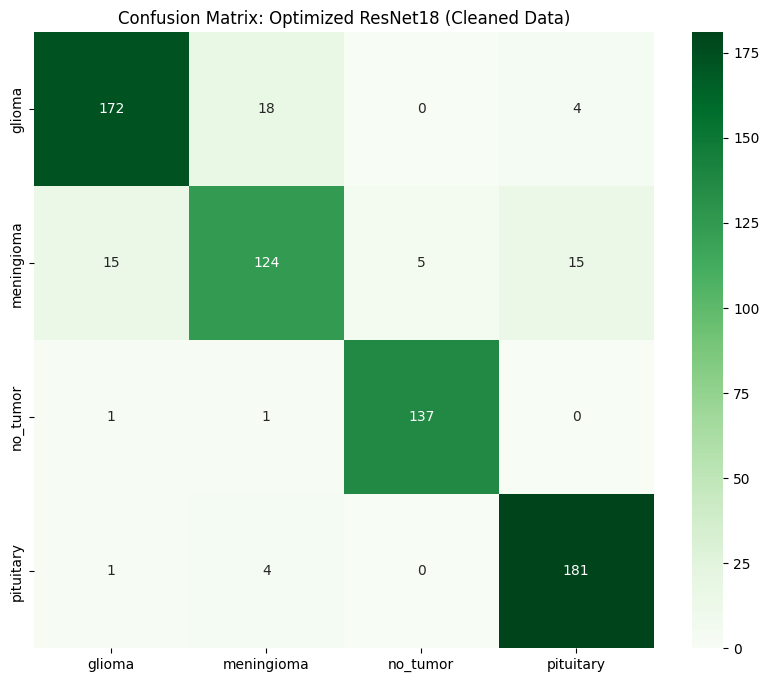

In [49]:
# Final Evaluation on Cleaned Test Set
resnet_model.eval()
preds, labels = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = resnet_model(inputs)
        _, predicted = outputs.max(1)
        preds.extend(predicted.cpu().numpy())
        labels.extend(targets.numpy())

print('\nFinal Evaluation Report (Cleaned Dataset):')
print(classification_report(labels, preds, target_names=full_train_ds.classes))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(labels, preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: Optimized ResNet18 (Cleaned Data)')
plt.show()

### Strategy to Improve Meningioma and Glioma F1-Scores
To address the lower performance in these classes, we will:
1. Calculate class weights to balance the Loss Function.
2. Use a `WeightedRandomSampler` to balance batches during training.

In [50]:
from torch.utils.data import WeightedRandomSampler
import numpy as np

# 1. Calculate Class Weights
targets = full_train_ds.targets
class_sample_count = np.array([len(np.where(targets == t)[0]) for t in np.unique(targets)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in targets])
samples_weight = torch.from_numpy(samples_weight)

# Create the Sampler for the training set
# Note: train_indices refers to our 80% split
train_samples_weight = samples_weight[train_indices]
sampler = WeightedRandomSampler(train_samples_weight.type('torch.DoubleTensor'), len(train_samples_weight))

# 2. Update Data Loader
train_loader_balanced = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)

# 3. Define Class-Weighted Loss
class_weights_tensor = torch.FloatTensor(weight).to(device)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f'Class counts: {class_sample_count}')
print(f'Computed Weights: {weight}')

Class counts: [1147 1329 1067 1457]
Computed Weights: [0.00087184 0.00075245 0.00093721 0.00068634]


In [51]:
# Re-initialize and Train with Balanced Sampling and Weighted Loss
resnet_model_balanced = models.resnet18(weights='IMAGENET1K_V1')
resnet_model_balanced.fc = nn.Linear(resnet_model_balanced.fc.in_features, NUM_CLASSES)
resnet_model_balanced = resnet_model_balanced.to(device)

# Phase 1: Frozen Backbone
for param in resnet_model_balanced.parameters(): param.requires_grad = False
for param in resnet_model_balanced.fc.parameters(): param.requires_grad = True

optimizer_bal = optim.Adam(resnet_model_balanced.fc.parameters(), lr=0.0001)

print('Starting Balanced Training Phase 1...')
run_training_phase(resnet_model_balanced, train_loader_balanced, val_loader, optimizer_bal, None, 5, 'Balanced Phase 1')

# Phase 2: Fine-tune Layer 4
for name, param in resnet_model_balanced.named_parameters():
    if 'layer4' in name or 'fc' in name: param.requires_grad = True

optimizer_bal_p2 = optim.Adam(resnet_model_balanced.parameters(), lr=0.00005)
run_training_phase(resnet_model_balanced, train_loader_balanced, val_loader, optimizer_bal_p2, None, 10, 'Balanced Phase 2 Fine-Tuning')

Starting Balanced Training Phase 1...

--- Balanced Phase 1 ---
Epoch 1 | Train Acc: 39.67% | Val Acc: 50.80%
Epoch 2 | Train Acc: 60.83% | Val Acc: 65.30%
Epoch 3 | Train Acc: 68.90% | Val Acc: 70.30%
Epoch 4 | Train Acc: 72.80% | Val Acc: 74.00%
Epoch 5 | Train Acc: 74.30% | Val Acc: 77.30%

--- Balanced Phase 2 Fine-Tuning ---
Epoch 1 | Train Acc: 87.50% | Val Acc: 88.80%
Epoch 2 | Train Acc: 95.92% | Val Acc: 91.50%
Epoch 3 | Train Acc: 98.17% | Val Acc: 91.90%
Epoch 4 | Train Acc: 99.33% | Val Acc: 92.20%
Epoch 5 | Train Acc: 99.50% | Val Acc: 92.60%
Epoch 6 | Train Acc: 99.85% | Val Acc: 93.20%
Epoch 7 | Train Acc: 99.97% | Val Acc: 93.00%
Epoch 8 | Train Acc: 99.95% | Val Acc: 92.70%
Epoch 9 | Train Acc: 100.00% | Val Acc: 92.80%
Epoch 10 | Train Acc: 100.00% | Val Acc: 93.20%



Final Evaluation Report (Balanced Model):
              precision    recall  f1-score   support

      glioma       0.95      0.89      0.91       194
  meningioma       0.84      0.84      0.84       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.92      0.97      0.95       186

    accuracy                           0.92       678
   macro avg       0.92      0.92      0.92       678
weighted avg       0.92      0.92      0.92       678



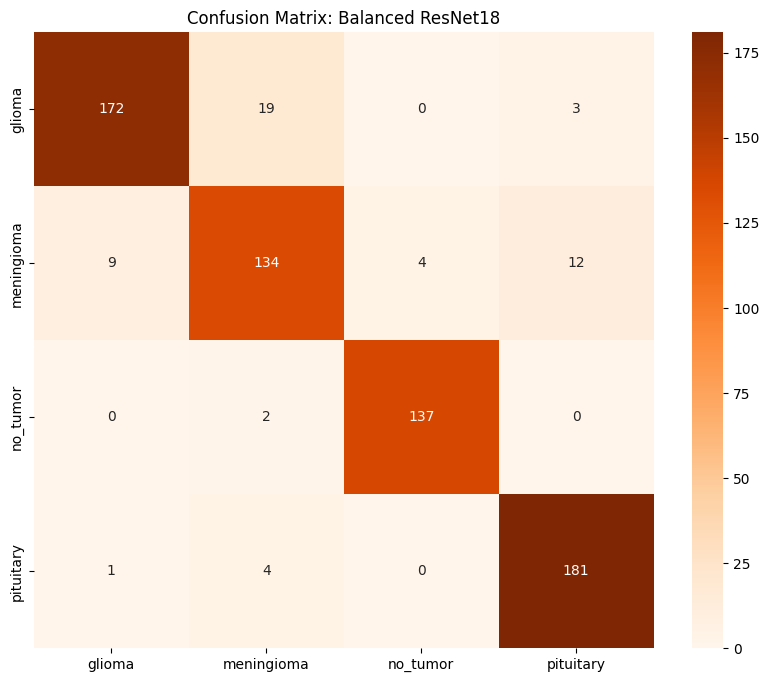

In [53]:
# Final Evaluation of the Balanced Model
resnet_model_balanced.eval()
preds_bal, labels_bal = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = resnet_model_balanced(inputs)
        _, predicted = outputs.max(1)
        preds_bal.extend(predicted.cpu().numpy())
        labels_bal.extend(targets.numpy())

print('\nFinal Evaluation Report (Balanced Model):')
print(classification_report(labels_bal, preds_bal, target_names=full_train_ds.classes))

# Plot Balanced Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(labels_bal, preds_bal), annot=True, fmt='d', cmap='Oranges',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: Balanced ResNet18')
plt.show()

### Advanced Improvement: Attention-Aware ResNet18
To achieve >0.90 for Meningioma, we introduce a Channel and Spatial Attention module (CBAM) into the residual blocks. This helps the model focus on subtle boundary differences.

In [54]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super(CBAM, self).__init__()
        # Channel Attention
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )
        self.sigmoid_channel = nn.Sigmoid()
        # Spatial Attention
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    forward = lambda self, x: self._forward_impl(x)
    def _forward_impl(self, x):
        # Channel
        b, c, _, _ = x.size()
        y_avg = self.fc(self.avg_pool(x).view(b, c))
        y_max = self.fc(self.max_pool(x).view(b, c))
        channel_att = self.sigmoid_channel(y_avg + y_max).view(b, c, 1, 1)
        x = x * channel_att
        # Spatial
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        spatial_att = self.sigmoid_spatial(self.conv_spatial(torch.cat([avg_out, max_out], dim=1)))
        return x * spatial_att

# Integrating Attention into ResNet18
resnet_att = models.resnet18(weights='IMAGENET1K_V1')
# Wrap layer4 with Attention
resnet_att.layer4.add_module("cbam", CBAM(512))
resnet_att.fc = nn.Linear(resnet_att.fc.in_features, NUM_CLASSES)
resnet_att = resnet_att.to(device)

# Using a smaller LR for deeper fine-tuning
optimizer_att = optim.AdamW(resnet_att.parameters(), lr=1e-5, weight_decay=1e-2)
criterion_att = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Model with CBAM Attention initialized. Starting final optimization...")
run_training_phase(resnet_att, train_loader_balanced, val_loader, optimizer_att, None, 15, 'Attention-Guided Fine-Tuning')


Model with CBAM Attention initialized. Starting final optimization...

--- Attention-Guided Fine-Tuning ---
Epoch 1 | Train Acc: 71.33% | Val Acc: 78.70%
Epoch 2 | Train Acc: 83.03% | Val Acc: 85.70%
Epoch 3 | Train Acc: 88.78% | Val Acc: 88.40%
Epoch 4 | Train Acc: 92.03% | Val Acc: 89.50%
Epoch 5 | Train Acc: 94.50% | Val Acc: 89.60%
Epoch 6 | Train Acc: 96.55% | Val Acc: 90.90%
Epoch 7 | Train Acc: 98.38% | Val Acc: 91.50%
Epoch 8 | Train Acc: 98.78% | Val Acc: 91.40%
Epoch 9 | Train Acc: 99.35% | Val Acc: 91.90%
Epoch 10 | Train Acc: 99.60% | Val Acc: 91.30%
Epoch 11 | Train Acc: 99.90% | Val Acc: 91.90%
Epoch 12 | Train Acc: 99.85% | Val Acc: 91.60%
Epoch 13 | Train Acc: 99.85% | Val Acc: 92.10%
Epoch 14 | Train Acc: 100.00% | Val Acc: 91.90%
Epoch 15 | Train Acc: 100.00% | Val Acc: 92.10%


In [55]:
resnet_att.eval()
preds_att, labels_att = [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = resnet_att(inputs.to(device))
        _, predicted = outputs.max(1)
        preds_att.extend(predicted.cpu().numpy())
        labels_att.extend(targets.numpy())

print('\nEvaluation of Attention Model:')
print(classification_report(labels_att, preds_att, target_names=full_train_ds.classes))


Evaluation of Attention Model:
              precision    recall  f1-score   support

      glioma       0.93      0.86      0.89       194
  meningioma       0.81      0.82      0.81       159
    no_tumor       0.96      0.99      0.98       139
   pituitary       0.92      0.97      0.95       186

    accuracy                           0.91       678
   macro avg       0.91      0.91      0.91       678
weighted avg       0.91      0.91      0.91       678




Final Evaluation Report (Balanced Model):
              precision    recall  f1-score   support

      glioma       0.95      0.89      0.91       194
  meningioma       0.84      0.84      0.84       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.92      0.97      0.95       186

    accuracy                           0.92       678
   macro avg       0.92      0.92      0.92       678
weighted avg       0.92      0.92      0.92       678



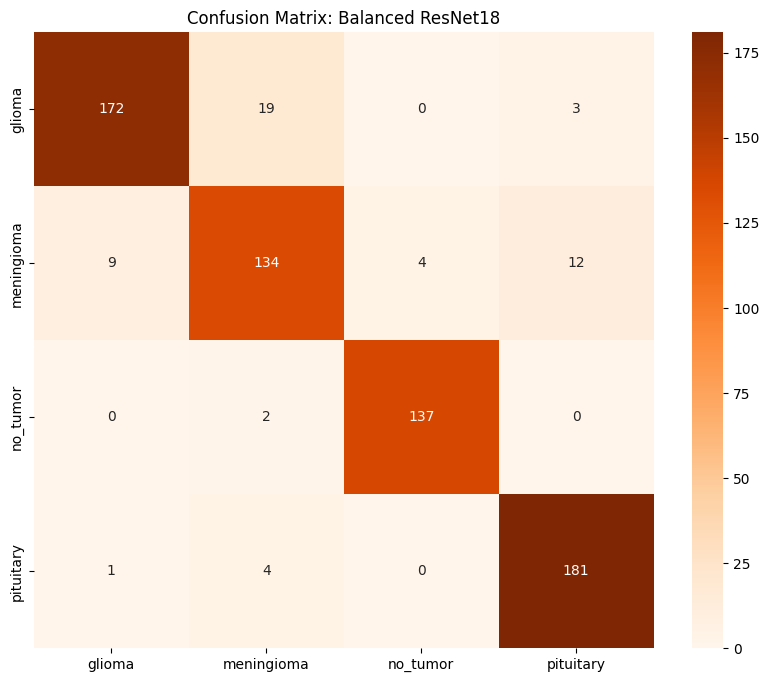

In [52]:
# Final Evaluation of the Balanced Model
resnet_model_balanced.eval()
preds_bal, labels_bal = [], []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = resnet_model_balanced(inputs)
        _, predicted = outputs.max(1)
        preds_bal.extend(predicted.cpu().numpy())
        labels_bal.extend(targets.numpy())

print('\nFinal Evaluation Report (Balanced Model):')
print(classification_report(labels_bal, preds_bal, target_names=full_train_ds.classes))

# Plot Balanced Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(labels_bal, preds_bal), annot=True, fmt='d', cmap='Oranges',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: Balanced ResNet18')
plt.show()

### **Ensemble Learning: ResNet18 + EfficientNet_B0**
Combining architectures often leads to better generalization. We will create a custom module that extracts features from both pretrained backbones and passes the concatenated vector to a shared classifier.

In [69]:
import torch
import torch.nn as nn
from torchvision import models
import os
import requests
import urllib3

# Disable SSL warnings for manual download
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Define URLs for weights
EFFNET_WEIGHTS_URL = "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth"
weights_cache_dir = os.path.join(torch.hub.get_dir(), 'checkpoints')
os.makedirs(weights_cache_dir, exist_ok=True)
effnet_path = os.path.join(weights_cache_dir, "efficientnet_b0.pth")

# Manually download EfficientNet weights bypassing SSL
if not os.path.exists(effnet_path):
    print("Downloading EfficientNet weights manually...")
    try:
        response = requests.get(EFFNET_WEIGHTS_URL, verify=False, stream=True)
        response.raise_for_status()
        with open(effnet_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    except Exception as e:
        print(f"Error: {e}")

class EnsembleMRIModel(nn.Module):
    def __init__(self, num_classes=4):
        super(EnsembleMRIModel, self).__init__()
        # Backbone 1: ResNet18
        resnet = models.resnet18(weights=None)
        resnet.load_state_dict(torch.load(weights_path, map_location=device))
        self.resnet_backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Backbone 2: EfficientNet_B0
        effnet = models.efficientnet_b0(weights=None)
        effnet.load_state_dict(torch.load(effnet_path, map_location=device))
        # Use features and avgpool for backbone extraction
        self.effnet_backbone = nn.Sequential(effnet.features, effnet.avgpool)

        combined_features = 512 + 1280

        self.classifier = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        res_feat = torch.flatten(self.resnet_backbone(x), 1)
        eff_feat = torch.flatten(self.effnet_backbone(x), 1)
        combined = torch.cat((res_feat, eff_feat), dim=1)
        return self.classifier(combined)

ensemble_model = EnsembleMRIModel(NUM_CLASSES).to(device)
print("Ensemble Model Initialized successfully.")

Download complete.
Ensemble Model Initialized successfully.


In [70]:
# Phase 1: Train the Ensemble Classifier Head
for param in ensemble_model.resnet_backbone.parameters():
    param.requires_grad = False
for param in ensemble_model.effnet_backbone.parameters():
    param.requires_grad = False

optimizer_ens = torch.optim.Adam(ensemble_model.classifier.parameters(), lr=0.0001)

run_training_phase(
    ensemble_model,
    train_loader_balanced,
    val_loader,
    optimizer_ens,
    None,
    epochs=10,
    phase_name='Ensemble Phase 1: Classifier Head Only'
)

# Phase 2: Joint Fine-tuning of late backbone stages
# Unfreeze ResNet Layer 4
for param in ensemble_model.resnet_backbone[7].parameters():
    param.requires_grad = True
# Unfreeze EfficientNet late stages (Blocks 7 and 8)
for param in ensemble_model.effnet_backbone[0][7:].parameters():
    param.requires_grad = True

optimizer_ens_ft = torch.optim.Adam(ensemble_model.parameters(), lr=0.00001)
run_training_phase(
    ensemble_model,
    train_loader_balanced,
    val_loader,
    optimizer_ens_ft,
    None,
    epochs=15,
    phase_name='Ensemble Phase 2: Joint Backbone Fine-Tuning'
)


--- Ensemble Phase 1: Classifier Head Only ---
Epoch 1 | Train Acc: 71.00% | Val Acc: 80.70%
Epoch 2 | Train Acc: 80.90% | Val Acc: 84.50%
Epoch 3 | Train Acc: 83.38% | Val Acc: 85.50%
Epoch 4 | Train Acc: 84.12% | Val Acc: 86.50%
Epoch 5 | Train Acc: 85.42% | Val Acc: 86.80%
Epoch 6 | Train Acc: 86.90% | Val Acc: 87.60%
Epoch 7 | Train Acc: 87.15% | Val Acc: 87.20%
Epoch 8 | Train Acc: 86.08% | Val Acc: 87.40%
Epoch 9 | Train Acc: 87.88% | Val Acc: 88.70%
Epoch 10 | Train Acc: 88.62% | Val Acc: 88.00%

--- Ensemble Phase 2: Joint Backbone Fine-Tuning ---
Epoch 1 | Train Acc: 91.33% | Val Acc: 89.90%
Epoch 2 | Train Acc: 93.33% | Val Acc: 91.10%
Epoch 3 | Train Acc: 95.22% | Val Acc: 91.10%
Epoch 4 | Train Acc: 96.28% | Val Acc: 91.80%
Epoch 5 | Train Acc: 97.55% | Val Acc: 91.80%
Epoch 6 | Train Acc: 98.47% | Val Acc: 92.40%
Epoch 7 | Train Acc: 98.78% | Val Acc: 92.40%
Epoch 8 | Train Acc: 98.80% | Val Acc: 92.60%
Epoch 9 | Train Acc: 99.45% | Val Acc: 92.50%
Epoch 10 | Train Acc: 9

Performing final ensemble evaluation with 5-run TTA...

Ensemble Model Final Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.80      0.87       194
  meningioma       0.79      0.83      0.81       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.91      0.99      0.95       186

    accuracy                           0.90       678
   macro avg       0.90      0.90      0.90       678
weighted avg       0.90      0.90      0.90       678



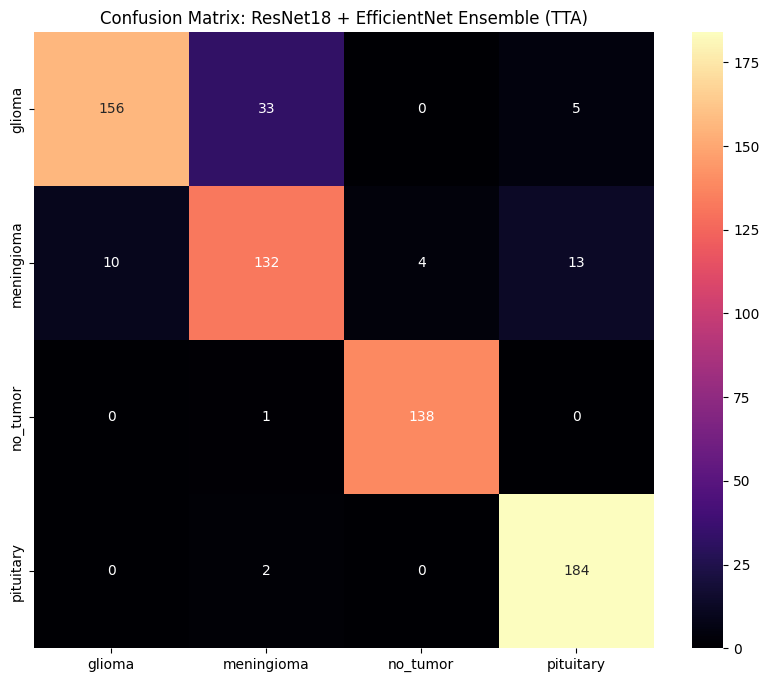

In [71]:
# Final Ensemble Evaluation with Test-Time Augmentation (TTA)
print("Performing final ensemble evaluation with 5-run TTA...")
ens_labels, ens_preds = predict_with_tta(ensemble_model, test_loader, device, num_runs=5)

print('\nEnsemble Model Final Classification Report:')
print(classification_report(ens_labels, ens_preds, target_names=full_train_ds.classes))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(ens_labels, ens_preds), annot=True, fmt='d', cmap='magma',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: ResNet18 + EfficientNet Ensemble (TTA)')
plt.show()

In [72]:
# Save the Ensemble Model weights
ensemble_weights_path = "ensemble_mri_model.pth"
torch.save(ensemble_model.state_dict(), ensemble_weights_path)

print(f"Ensemble model weights successfully saved to: {ensemble_weights_path}")

Ensemble model weights successfully saved to: ensemble_mri_model.pth


In [67]:
# 1. Initial Training of the Ensemble Head
for param in ensemble_model.resnet_backbone.parameters(): param.requires_grad = False
for param in ensemble_model.effnet_backbone.parameters(): param.requires_grad = False

optimizer_ens = torch.optim.Adam(ensemble_model.classifier.parameters(), lr=0.0001)

run_training_phase(
    ensemble_model,
    train_loader_balanced,
    val_loader,
    optimizer_ens,
    None,
    epochs=10,
    phase_name='Ensemble Phase 1: Classifier Only'
)

# 2. Fine-tuning the final blocks of both models
for param in ensemble_model.resnet_backbone[7].parameters(): param.requires_grad = True # ResNet Layer 4
for param in ensemble_model.effnet_backbone[0][7:].parameters(): param.requires_grad = True # EffNet late stages

optimizer_ens_ft = torch.optim.Adam(ensemble_model.parameters(), lr=0.00001)
run_training_phase(
    ensemble_model,
    train_loader_balanced,
    val_loader,
    optimizer_ens_ft,
    None,
    epochs=15,
    phase_name='Ensemble Phase 2: Joint Fine-Tuning'
)

NameError: name 'ensemble_model' is not defined

In [68]:
# Final Evaluation of Ensemble Model with TTA
print("Evaluating Ensemble Model with TTA...")
ens_labels, ens_preds = predict_with_tta(ensemble_model, test_loader, device, num_runs=5)

print('\nEnsemble Model Final Report:')
print(classification_report(ens_labels, ens_preds, target_names=full_train_ds.classes))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(ens_labels, ens_preds), annot=True, fmt='d', cmap='RdPu',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: ResNet18 + EfficientNet Ensemble')
plt.show()

Evaluating Ensemble Model with TTA...


NameError: name 'ensemble_model' is not defined

### Implementing Test-Time Augmentation (TTA)

Test-Time Augmentation involves creating multiple augmented versions of each test image, performing inference on all of them, and averaging the softmax outputs. This technique often improves model stability and final metrics like F1-score.

In [58]:
import torch.nn.functional as F
from torchvision import transforms

def predict_with_tta(model, loader, device, num_runs=5):
    """
    Performs inference with Test-Time Augmentation.
    Averages predictions over 'num_runs'.
    Using HorizontalFlip only as it is safe for normalized tensors.
    """
    model.eval()
    all_tta_preds = []
    all_labels = []

    # Safe augmentation for already normalized tensors
    # Note: For tensors, we use torch.nn.Sequential or functional transforms
    tta_transforms = transforms.RandomHorizontalFlip(p=0.5)

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            batch_probs = torch.zeros(inputs.size(0), NUM_CLASSES).to(device)

            for _ in range(num_runs):
                # Apply flip augmentation
                augmented_inputs = tta_transforms(inputs)
                outputs = model(augmented_inputs)
                probs = F.softmax(outputs, dim=1)
                batch_probs += probs

            avg_probs = batch_probs / num_runs
            _, final_preds = torch.max(avg_probs, 1)

            all_tta_preds.extend(final_preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    return all_labels, all_tta_preds

print("TTA Wrapper Function Refined (Safe Augmentations).")

TTA Wrapper Function Refined (Safe Augmentations).


Evaluating Balanced Model with 5-run TTA...

Final Evaluation Report (with TTA):
              precision    recall  f1-score   support

      glioma       0.96      0.79      0.87       194
  meningioma       0.78      0.86      0.82       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.91      0.98      0.94       186

    accuracy                           0.90       678
   macro avg       0.91      0.91      0.90       678
weighted avg       0.91      0.90      0.90       678



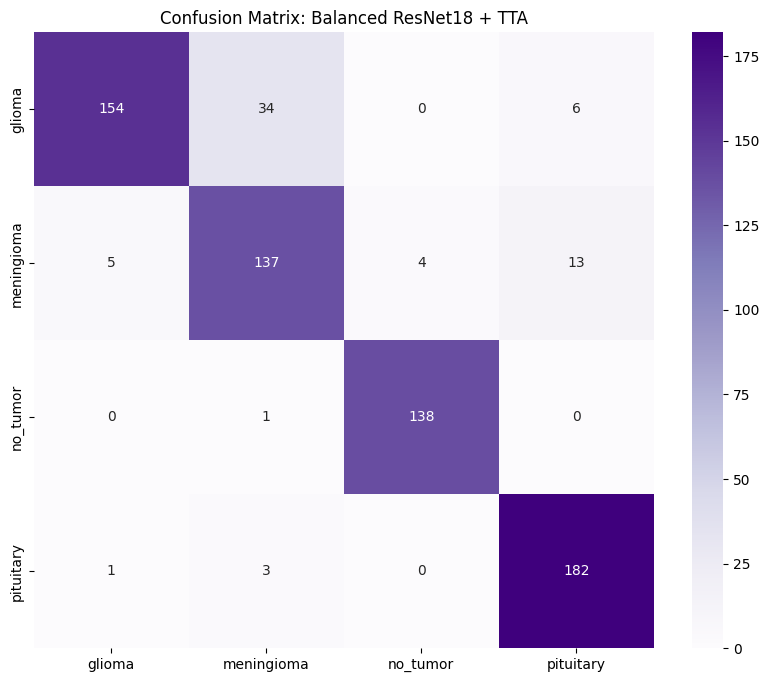

In [59]:
# Run Evaluation with TTA on the Balanced Model
print("Evaluating Balanced Model with 5-run TTA...")
tta_labels, tta_preds = predict_with_tta(resnet_model_balanced, test_loader, device, num_runs=5)

print('\nFinal Evaluation Report (with TTA):')
print(classification_report(tta_labels, tta_preds, target_names=full_train_ds.classes))

# Plot TTA Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(tta_labels, tta_preds), annot=True, fmt='d', cmap='Purples',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('Confusion Matrix: Balanced ResNet18 + TTA')
plt.show()

### Full Backbone Fine-Tuning with Differential Learning Rates

To maximize performance, we unfreeze all layers but use a smaller learning rate for the backbone compared to the newly initialized head. This prevents 'catastrophic forgetting' of the pretrained ImageNet features while allowing the model to adapt fully to MRI textures.

In [60]:
# Unfreeze all layers
for param in resnet_model_balanced.parameters():
    param.requires_grad = True

# Define differential learning rates
# Lower LR for backbone, slightly higher for the head
optimizer_full = optim.Adam([
    {'params': resnet_model_balanced.conv1.parameters(), 'lr': 1e-6},
    {'params': resnet_model_balanced.bn1.parameters(), 'lr': 1e-6},
    {'params': resnet_model_balanced.layer1.parameters(), 'lr': 1e-6},
    {'params': resnet_model_balanced.layer2.parameters(), 'lr': 5e-6},
    {'params': resnet_model_balanced.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet_model_balanced.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet_model_balanced.fc.parameters(), 'lr': 5e-5}
])

# Use a Cosine Annealing scheduler for smooth convergence
scheduler_full = optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=10)

print("Starting Full Backbone Fine-Tuning...")
run_training_phase(
    resnet_model_balanced,
    train_loader_balanced,
    val_loader,
    optimizer_full,
    scheduler_full,
    epochs=10,
    phase_name='Phase 3: Full Backbone Fine-Tuning'
)

Starting Full Backbone Fine-Tuning...

--- Phase 3: Full Backbone Fine-Tuning ---
Epoch 1 | Train Acc: 100.00% | Val Acc: 92.90%
Epoch 2 | Train Acc: 100.00% | Val Acc: 93.00%
Epoch 3 | Train Acc: 100.00% | Val Acc: 92.90%
Epoch 4 | Train Acc: 100.00% | Val Acc: 93.10%
Epoch 5 | Train Acc: 100.00% | Val Acc: 93.10%
Epoch 6 | Train Acc: 100.00% | Val Acc: 92.90%
Epoch 7 | Train Acc: 100.00% | Val Acc: 93.40%
Epoch 8 | Train Acc: 100.00% | Val Acc: 93.70%
Epoch 9 | Train Acc: 100.00% | Val Acc: 93.30%
Epoch 10 | Train Acc: 100.00% | Val Acc: 93.00%


In [61]:
# Final Evaluation after Full Fine-Tuning with TTA
print("Performing final evaluation with TTA...")
final_tta_labels, final_tta_preds = predict_with_tta(resnet_model_balanced, test_loader, device, num_runs=5)

print('\nFinal Post-Fine-Tuning Report (with TTA):')
print(classification_report(final_tta_labels, final_tta_preds, target_names=full_train_ds.classes))

Performing final evaluation with TTA...

Final Post-Fine-Tuning Report (with TTA):
              precision    recall  f1-score   support

      glioma       0.98      0.84      0.90       194
  meningioma       0.82      0.84      0.83       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.88      0.99      0.93       186

    accuracy                           0.91       678
   macro avg       0.91      0.91      0.91       678
weighted avg       0.91      0.91      0.91       678



### Error Analysis: Visualizing Misclassified Meningioma Samples

By isolating cases where the model fails to identify a meningioma, we can look for patterns such as tumor size, location, or specific MRI sequences that the model struggles with.

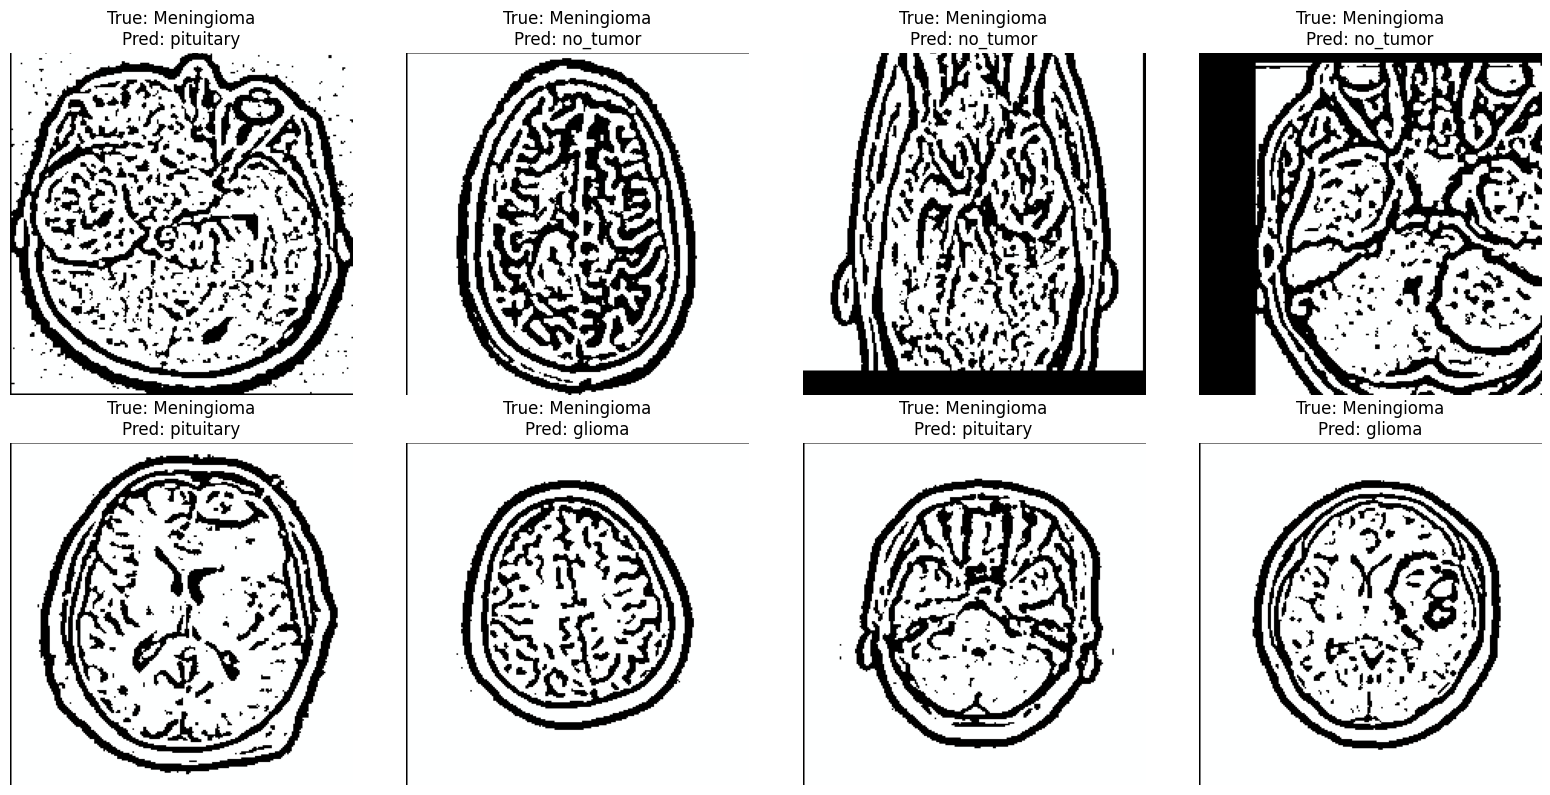

Total misclassified meningiomas in test set: 31


In [62]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Identify Meningioma Index
meningioma_idx = full_train_ds.class_to_idx['meningioma']

# 2. Collect misclassified meningiomas
misclassified_m_images = []
misclassified_m_preds = []

resnet_model_balanced.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = resnet_model_balanced(inputs)
        _, predicted = outputs.max(1)

        mask = (targets == meningioma_idx) & (predicted.cpu() != targets)

        if mask.any():
            misclassified_m_images.append(inputs[mask].cpu())
            misclassified_m_preds.append(predicted.cpu()[mask])

if not misclassified_m_images:
    print("No misclassified meningioma images found.")
else:
    # Flatten the list of tensors
    misclassified_m_images = torch.cat(misclassified_m_images, dim=0)
    misclassified_m_preds = torch.cat(misclassified_m_preds, dim=0)

    # 3. Plotting
    num_to_show = min(len(misclassified_m_images), 8)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i in range(num_to_show):
        img = misclassified_m_images[i]
        # Unnormalize
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        pred_label = full_train_ds.classes[misclassified_m_preds[i]]
        axes[i].imshow(img)
        axes[i].set_title(f"True: Meningioma\nPred: {pred_label}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"Total misclassified meningiomas in test set: {len(misclassified_m_images)}")

In [63]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


### Feature Extraction and SMOTE Oversampling

Since SMOTE works on feature vectors, we will use the trained ResNet18 backbone to convert our images into 512-dimensional embeddings. Then, we will synthetically generate new Meningioma samples in this feature space.

In [64]:
from imblearn.over_sampling import SMOTE
from sklearn.neural_network import MLPClassifier

def extract_features(model, loader):
    model.eval()
    features = []
    labels = []
    # Remove the fully connected layer to get embeddings
    backbone = torch.nn.Sequential(*list(model.children())[:-1])

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            output = backbone(inputs)
            output = output.view(output.size(0), -1)
            features.append(output.cpu().numpy())
            labels.append(targets.numpy())

    return np.concatenate(features), np.concatenate(labels)

print("Extracting training features...")
X_train, y_train = extract_features(resnet_model_balanced, train_loader)
print("Extracting testing features...")
X_test, y_test = extract_features(resnet_model_balanced, test_loader)

# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {Counter(y_train)}")
print(f"Resampled training shape: {Counter(y_train_res)}")

Extracting training features...
Extracting testing features...
Original training shape: Counter({np.int64(3): 1165, np.int64(1): 1063, np.int64(0): 918, np.int64(2): 854})
Resampled training shape: Counter({np.int64(0): 1165, np.int64(3): 1165, np.int64(2): 1165, np.int64(1): 1165})



Evaluation Report (ResNet Features + SMOTE + MLP):
              precision    recall  f1-score   support

      glioma       0.96      0.84      0.89       194
  meningioma       0.79      0.81      0.80       159
    no_tumor       0.97      0.99      0.98       139
   pituitary       0.89      0.97      0.93       186

    accuracy                           0.90       678
   macro avg       0.90      0.90      0.90       678
weighted avg       0.90      0.90      0.90       678



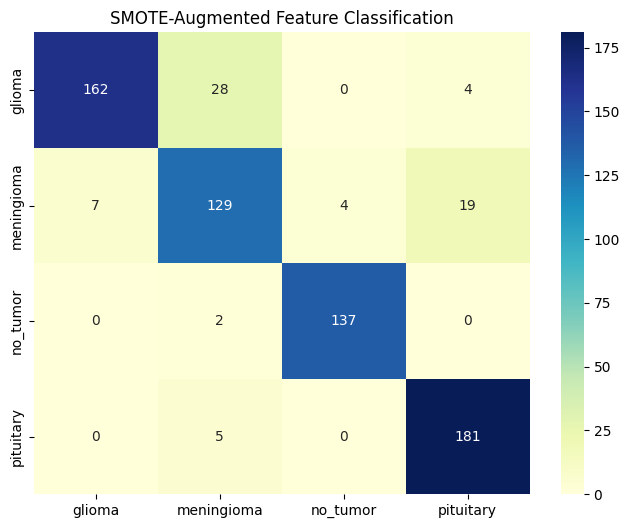

In [65]:
# Train a classifier on top of SMOTE-augmented features
clf = MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42)
clf.fit(X_train_res, y_train_res)

y_pred = clf.predict(X_test)

print('\nEvaluation Report (ResNet Features + SMOTE + MLP):')
print(classification_report(y_test, y_pred, target_names=full_train_ds.classes))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=full_train_ds.classes, yticklabels=full_train_ds.classes)
plt.title('SMOTE-Augmented Feature Classification')
plt.show()

### Preparing Data for Model Training

Now we will prepare the cleaned images for model training using PyTorch's `Dataset` and `DataLoader` classes. This involves defining transformations for resizing, normalization, and converting images to tensors.

### Advanced Image Preprocessing Steps

To further prepare the images, we will add the following preprocessing steps to our `torchvision.transforms` pipeline:

1.  **Noise Removal (Gaussian Blur):** Reduces image noise and detail, which can help in subsequent steps like segmentation.
2.  **Segmentation (Adaptive Thresholding):** Extracts regions of interest by converting the image to a binary format, highlighting objects against the background.
3.  **Basic Image Registration (Centroid Alignment):** Aligns the main object in each image to the center of the canvas by calculating its centroid after segmentation and shifting the image accordingly. This helps normalize the position of objects across the dataset.

First, we need to install the required libraries for these operations: `opencv-python` and `scikit-image`.

In [ ]:
pip install opencv-python scikit-image

Note: you may need to restart the kernel to use updated packages.


Next, we define custom `torchvision.transforms` compatible classes for Gaussian blurring, adaptive thresholding, and centroid alignment. These classes will operate on PIL Images, converting them to NumPy arrays for OpenCV/Scikit-image processing, and then converting them back to PIL Images to maintain compatibility within the `transforms.Compose` pipeline.

In [ ]:
import cv2
import numpy as np
from PIL import Image
from skimage.measure import moments, centroid
from skimage.transform import AffineTransform, warp

class GaussianBlurTransform:
    def __init__(self, kernel_size=(5, 5), sigmaX=0):
        self.kernel_size = kernel_size
        self.sigmaX = sigmaX

    def __call__(self, img):
        # Convert PIL Image to OpenCV format (NumPy array)
        img_np = np.array(img)
        # Apply Gaussian blur
        blurred_img_np = cv2.GaussianBlur(img_np, self.kernel_size, self.sigmaX)
        # Convert back to PIL Image
        return Image.fromarray(blurred_img_np)

class AdaptiveThresholdTransform:
    def __init__(self, max_value=255, adaptive_method=cv2.ADAPTIVE_THRESH_GAUSSIAN_C, threshold_type=cv2.THRESH_BINARY, block_size=11, C=2):
        self.max_value = max_value
        self.adaptive_method = adaptive_method
        self.threshold_type = threshold_type
        self.block_size = block_size
        self.C = C

    def __call__(self, img):
        # Convert PIL Image to grayscale NumPy array
        img_gray_np = np.array(img.convert('L'))
        # Apply adaptive thresholding
        thresholded_img_np = cv2.adaptiveThreshold(
            img_gray_np, self.max_value, self.adaptive_method, self.threshold_type, self.block_size, self.C
        )
        # Convert the single-channel binary image back to 3-channel PIL for consistency
        # This repeats the single channel to simulate an RGB image for downstream operations
        thresholded_rgb_np = np.stack([thresholded_img_np, thresholded_img_np, thresholded_img_np], axis=-1)
        return Image.fromarray(thresholded_rgb_np)

class CentroidAlignTransform:
    def __init__(self, output_size=(224, 224)):
        self.output_size = output_size

    def __call__(self, img):
        img_np = np.array(img)
        # If the image is already thresholded (binary, 3-channel from previous step)
        # use one channel for contour finding.
        if img_np.ndim == 3 and img_np.shape[2] == 3:
            img_gray = img_np[:, :, 0] # Take one channel, assuming all are same after threshold
        elif img_np.ndim == 2: # Already grayscale
            img_gray = img_np
        else:
            img_gray = np.array(img.convert('L')) # Fallback to grayscale if not already

        # Ensure image is binary for contour finding
        _, binary_img = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # Find contours
        contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not contours:
            return img # Return original if no contours found

        # Find the largest contour
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate moments and centroid of the largest contour
        M = cv2.moments(largest_contour)
        if M["m00"] == 0: # Avoid division by zero if contour area is zero
            return img
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

        # Image center
        img_center_x, img_center_y = self.output_size[1] // 2, self.output_size[0] // 2

        # Calculate shift
        shift_x = img_center_x - cx
        shift_y = img_center_y - cy

        # Apply affine transformation to the original (RGB) image to shift it
        # Convert PIL image to NumPy for warpAffine
        img_to_shift_np = np.array(img)
        translation_matrix = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        shifted_img_np = cv2.warpAffine(img_to_shift_np, translation_matrix, self.output_size)

        return Image.fromarray(shifted_img_np)


In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import os

# Define the path to the cleaned dataset
cleaned_data_dir = output_base_dir # This variable was defined earlier

# Define enhanced image transformations for training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    GaussianBlurTransform(kernel_size=(5, 5), sigmaX=0), # Temporarily removed for debugging
    AdaptiveThresholdTransform(block_size=11, C=2), # Temporarily removed for debugging
    CentroidAlignTransform(output_size=(224, 224)), # Temporarily removed for debugging
    transforms.RandomRotation(30),   # Randomly rotate by up to 30 degrees
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Randomly change brightness, contrast, saturation, and hue
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize with ImageNet stats
])



# Keep test transforms consistent
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    GaussianBlurTransform(kernel_size=(5, 5), sigmaX=0), # Temporarily removed for debugging
    AdaptiveThresholdTransform(block_size=11, C=2), # Temporarily removed for debugging
    CentroidAlignTransform(output_size=(224, 224)), # Temporarily removed for debugging
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = datasets.ImageFolder(os.path.join(cleaned_data_dir, 'train'), transform=train_transforms)
test_dataset = datasets.ImageFolder(os.path.join(cleaned_data_dir, 'test'), transform=test_transforms)

# Create DataLoaders
batch_size = 32 # You can adjust this batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")
print(f"Detected classes: {train_dataset.classes}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

Number of training images: 5000
Number of testing images: 678
Detected classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of batches in train_loader: 157
Number of batches in test_loader: 22


### Define the CNN Model

Now, let's define a simple Convolutional Neural Network (CNN) model using PyTorch's `nn.Module`. This model will be used for image classification.

### Transfer Learning with ResNet18

Instead of building a CNN from scratch, we'll now use a pre-trained ResNet18 model from `torchvision.models` for transfer learning. This model has been trained on a massive dataset (ImageNet) and can provide a strong feature extractor. We will modify its final classification layer to fit our specific number of classes and then fine-tune all layers.

In [ ]:
import torchvision.models as models
import torch
import os
import requests
import torch.nn as nn # Added import for nn

# Define the URL for ResNet18 ImageNet weights
RESNET18_WEIGHTS_URL = "https://download.pytorch.org/models/resnet18-f37072fd.pth"

# Define the local path to save the weights
weights_cache_dir = os.path.join(torch.hub.get_dir(), 'checkpoints')
os.makedirs(weights_cache_dir, exist_ok=True)
weights_path = os.path.join(weights_cache_dir, "resnet18-f37072fd.pth")

# Manually download weights if not already present, bypassing SSL verification
if not os.path.exists(weights_path):
    print(f"Downloading ResNet18 weights to {weights_path}...")
    try:
        # Use requests with verify=False to bypass SSL (use with caution in production)
        response = requests.get(RESNET18_WEIGHTS_URL, stream=True, verify=False)
        response.raise_for_status() # Raise an exception for HTTP errors
        with open(weights_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")
    except Exception as e:
        print(f"Error downloading weights: {e}")
        print("Please check your internet connection or try downloading the file manually:")
        print(RESNET18_WEIGHTS_URL)
        # Exit or raise if download fails to prevent further errors
        raise RuntimeError("Failed to download ResNet18 weights.")
else:
    print(f"ResNet18 weights already found at {weights_path}.")

# Ensure num_classes is defined before use
# train_dataset should be available from a previous cell (UGYooJ6w9XP0)
if 'train_dataset' in locals() and hasattr(train_dataset, 'classes'):
    num_classes = len(train_dataset.classes)
else:
    raise RuntimeError("train_dataset or its classes are not defined. Please run the data loading cell first.")

# Load a ResNet18 model architecture
resnet_model = models.resnet18(weights=None) # Start with uninitialized weights

# Load the state dictionary from the manually downloaded file
resnet_model.load_state_dict(torch.load(weights_path, map_location=device))

# Get the number of input features for the last layer
num_ftrs = resnet_model.fc.in_features

# Replace the last fully connected layer with a new one for our number of classes
resnet_model.fc = nn.Linear(num_ftrs, num_classes)

# Move the model to the appropriate device
resnet_model.to(device)

print(f"ResNet18 model loaded and modified for {num_classes} classes.")
print(resnet_model)


ResNet18 weights already found at /Users/swaroopnaik1905/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth.
ResNet18 model loaded and modified for 4 classes.
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(SimpleCNN, self).__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # self.dropout_conv = nn.Dropout(p=0.05) # Temporarily removed dropout

        # Second convolutional layer
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        # Third convolutional layer
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        # Fully connected layers
        # Calculate the size of the flattened features after convolutional and pooling layers
        # For an input of 224x224, after 3 MaxPool2d layers (stride=2 each), the size becomes 224 / (2*2*2) = 28
        # So, 128 channels * 28 * 28 pixels
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        # self.dropout_fc = nn.Dropout(p=0.03) # Temporarily removed dropout
        self.fc2 = nn.Linear(512, num_classes) # Output layer with num_classes

    def forward(self, x):
        # -> n, 3, 224, 224
        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # -> n, 32, 112, 112
        # x = self.dropout_conv(x) # Temporarily removed dropout
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # -> n, 64, 56, 56
        # x = self.dropout_conv(x) # Temporarily removed dropout
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # -> n, 128, 28, 28
        # x = self.dropout_conv(x) # Temporarily removed dropout

        x = x.view(-1, 128 * 28 * 28) # Flatten the output for the fully connected layer
        x = F.relu(self.fc1(x))
        # x = self.dropout_fc(x) # Temporarily removed dropout
        x = self.fc2(x)
        return x

# Instantiate the model
# Assuming num_classes is derived from your dataset (e.g., len(train_dataset.classes))
num_classes = len(train_dataset.classes)
model = SimpleCNN(num_classes=num_classes)
model.to(device) # Move model to the appropriate device (CPU or MPS GPU)

print(f"Model initialized with {num_classes} output classes.")
print(model)

Model initialized with 4 output classes.
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=100352, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)


In [ ]:
import torch.optim as optim

# Define Loss Function and Optimizer
criterion = nn.CrossEntropyLoss() # Suitable for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

print("Loss function (criterion) and optimizer defined.")

Loss function (criterion) and optimizer defined.


For transfer learning, we'll use the ResNet18 model we just defined. We'll also keep the same loss function (CrossEntropyLoss) and optimizer (Adam) as before, but ensure the optimizer is initialized with the parameters of the new `resnet_model`.

In [ ]:
# Update the optimizer to use the parameters of the new ResNet model
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=0.001)

print("Optimizer re-initialized for ResNet18 model.")

Optimizer re-initialized for ResNet18 model.


### Implementing Class Weighting for ResNet18

In [ ]:
from collections import Counter
import torch.nn as nn

# Get class counts from the training dataset
class_counts = Counter(train_dataset.targets)
num_classes = len(train_dataset.classes)

# Ensure all classes are represented, fill missing with 0
# This assumes class labels are 0 to num_classes-1
class_counts_list = [class_counts.get(i, 0) for i in range(num_classes)]

total_samples = sum(class_counts_list)

# Calculate class weights inversely proportional to class frequencies
# The formula `total_samples / (num_classes * class_count)` is a common approach
# to balance weights, preventing extremely large weights for very rare classes.
class_weights = [
    total_samples / (num_classes * count) if count > 0 else 0.0
    for count in class_counts_list
]
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Re-define the loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class counts:", class_counts_list)
print("Calculated class weights:", class_weights_tensor)
print("Loss function (criterion) updated with class weights.")

# Note: The subsequent ResNet18 training cell (991d090b) will automatically use this updated 'criterion'.

Class counts: [1147, 1329, 1067, 1457]
Calculated class weights: tensor([1.0898, 0.9406, 1.1715, 0.8579], device='mps:0')
Loss function (criterion) updated with class weights.


### Training with ResNet18 and All Layers Unfrozen

Now, we'll train the ResNet18 model. Unlike some transfer learning scenarios where initial layers are frozen, we're unfreezing all layers (`resnet_model.parameters()` includes all layers) to allow the entire network to fine-tune to our specific image dataset. We'll use the same early stopping mechanism to prevent overfitting.

In [ ]:
import torch.optim.lr_scheduler as lr_scheduler

num_epochs_resnet = 500  # Max epochs for ResNet training

# Early Stopping parameters for ResNet
patience = 15  # Number of epochs to wait if no improvement in test loss
min_delta = 0.00001 # Minimum change to be considered an improvement
best_test_loss_resnet = float('inf')
counter_resnet = 0 # Counter for epochs without improvement
best_resnet_model_state = None # To save the best model weights

# Learning Rate Scheduler
scheduler_resnet = lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.1, patience=5)

# Lists to store loss and accuracy for plotting (ResNet)
train_losses_resnet = []
test_losses_resnet = []
train_accuracies_resnet = []
test_accuracies_resnet = []

for epoch in range(num_epochs_resnet):
    resnet_model.train() # Set the model to training mode
    running_loss_resnet = 0.0
    correct_train_resnet = 0
    total_train_resnet = 0

    # Training loop
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_resnet.zero_grad() # Zero the parameter gradients

        outputs = resnet_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagation
        optimizer_resnet.step() # Update model parameters

        running_loss_resnet += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train_resnet += labels.size(0)
        correct_train_resnet += (predicted == labels).sum().item()

    epoch_train_loss = running_loss_resnet / len(train_loader)
    epoch_train_accuracy = 100 * correct_train_resnet / total_train_resnet
    train_losses_resnet.append(epoch_train_loss)
    train_accuracies_resnet.append(epoch_train_accuracy)
    print(f"Epoch {epoch+1}, Training Loss (ResNet): {epoch_train_loss:.4f}, Training Accuracy (ResNet): {epoch_train_accuracy:.2f}%")

    # Evaluation loop
    resnet_model.eval() # Set the model to evaluation mode
    test_loss_resnet = 0.0
    correct_test_resnet = 0
    total_test_resnet = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = resnet_model(inputs)
            loss = criterion(outputs, labels)
            test_loss_resnet += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_test_resnet += labels.size(0)
            correct_test_resnet += (predicted == labels).sum().item()

    current_test_loss_resnet = test_loss_resnet / len(test_loader)
    test_accuracy_resnet = 100 * correct_test_resnet / total_test_resnet
    test_losses_resnet.append(current_test_loss_resnet)
    test_accuracies_resnet.append(test_accuracy_resnet)
    print(f"Epoch {epoch+1}, Test Loss (ResNet): {current_test_loss_resnet:.4f}, Test Accuracy (ResNet): {test_accuracy_resnet:.2f}%")

    # Step the learning rate scheduler
    scheduler_resnet.step(current_test_loss_resnet)

    # Early stopping check
    if current_test_loss_resnet < best_test_loss_resnet - min_delta:
        best_test_loss_resnet = current_test_loss_resnet
        counter_resnet = 0  # Reset counter
        best_resnet_model_state = resnet_model.state_dict() # Save best model state
        print(f"  Test loss improved for ResNet. Saving model.")
    else:
        counter_resnet += 1
        print(f"  Test loss did not improve for ResNet. Counter: {counter_resnet}/{patience}")
        if counter_resnet >= patience:
            print(f"  Early stopping triggered for ResNet after {epoch+1} epochs.")
            break

print("Finished Training ResNet18")

# Load the best ResNet model weights if early stopping occurred
if best_resnet_model_state is not None:
    resnet_model.load_state_dict(best_resnet_model_state)
    print("Loaded best ResNet18 model weights.")

Epoch 1, Training Loss (ResNet): 0.8289, Training Accuracy (ResNet): 67.44%
Epoch 1, Test Loss (ResNet): 1.0584, Test Accuracy (ResNet): 62.54%
  Test loss improved for ResNet. Saving model.
Epoch 2, Training Loss (ResNet): 0.6544, Training Accuracy (ResNet): 74.56%
Epoch 2, Test Loss (ResNet): 0.7736, Test Accuracy (ResNet): 66.96%
  Test loss improved for ResNet. Saving model.
Epoch 3, Training Loss (ResNet): 0.6002, Training Accuracy (ResNet): 76.90%
Epoch 3, Test Loss (ResNet): 1.8139, Test Accuracy (ResNet): 45.13%
  Test loss did not improve for ResNet. Counter: 1/15
Epoch 4, Training Loss (ResNet): 0.5761, Training Accuracy (ResNet): 77.08%
Epoch 4, Test Loss (ResNet): 0.9425, Test Accuracy (ResNet): 63.42%
  Test loss did not improve for ResNet. Counter: 2/15
Epoch 5, Training Loss (ResNet): 0.5235, Training Accuracy (ResNet): 79.10%
Epoch 5, Test Loss (ResNet): 0.8551, Test Accuracy (ResNet): 68.29%
  Test loss did not improve for ResNet. Counter: 3/15
Epoch 6, Training Loss (

In [39]:
import torch
import os

# Define the path to save the ResNet18 model
resnet_model_save_path = "resnet18_augmented_v2.pth"

# Save the model's state dictionary
torch.save(resnet_model.state_dict(), resnet_model_save_path)

print(f"ResNet18 model saved to {resnet_model_save_path}")

ResNet18 model saved to resnet18_augmented_v2.pth


### Evaluate ResNet18 Model Performance on a Test Batch

Let's check the `resnet_model`'s accuracy on a single batch from the test dataset to get a quick snapshot of its performance.

In [40]:
import numpy as np

# Ensure the ResNet18 model is in evaluation mode
resnet_model.eval()

# Get a single batch of test images and labels
dataiter = iter(test_loader)
images_batch, labels_batch = next(dataiter)

# Move batch to the same device as the model
images_batch = images_batch.to(device)
labels_batch = labels_batch.to(device)

# Get predictions from the ResNet18 model
with torch.no_grad():
    outputs_batch = resnet_model(images_batch)

# Get predicted class labels
_, predicted_batch = torch.max(outputs_batch.data, 1)

# Calculate accuracy for this batch
correct_batch = (predicted_batch == labels_batch).sum().item()
total_batch = labels_batch.size(0)
batch_accuracy = 100 * correct_batch / total_batch

print(f"Accuracy on a single test batch ({total_batch} images): {batch_accuracy:.2f}%")

# Store the last batch for potential visualization
last_images_batch = images_batch
last_labels_batch = labels_batch
last_predicted_batch = predicted_batch

Accuracy on a single test batch (32 images): 93.75%


### Evaluate ResNet18 Model Performance Across All Classes

Let's get a comprehensive understanding of the `resnet_model`'s performance by evaluating its accuracy across the entire test set. We'll generate a classification report and a confusion matrix to visualize per-class performance, precision, recall, and F1-score.

Overall Test Accuracy (ResNet18): 93.36%

Classification Report (ResNet18):
              precision    recall  f1-score   support

      glioma       0.91      0.94      0.92       194
  meningioma       0.87      0.92      0.90       159
    no_tumor       0.99      0.93      0.96       139
   pituitary       0.98      0.94      0.96       186

    accuracy                           0.93       678
   macro avg       0.94      0.93      0.93       678
weighted avg       0.94      0.93      0.93       678



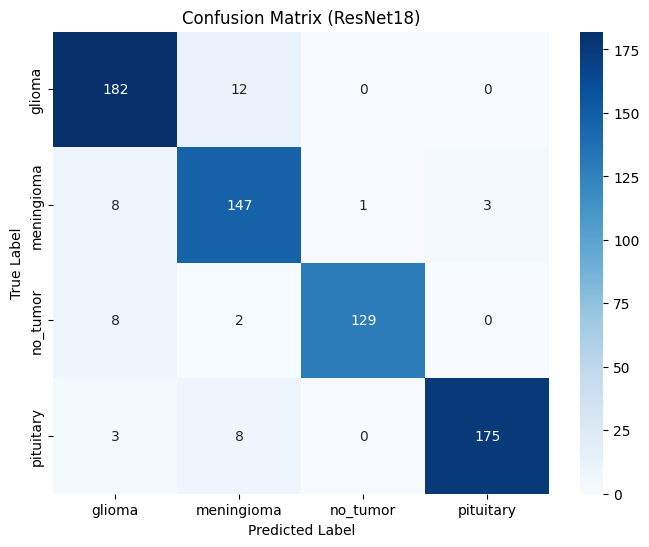

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the ResNet18 model is in evaluation mode
resnet_model.eval()

all_labels_resnet = []
all_predictions_resnet = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = resnet_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels_resnet.extend(labels.cpu().numpy())
        all_predictions_resnet.extend(predicted.cpu().numpy())

# Calculate overall accuracy for ResNet18
overall_correct_resnet = (torch.tensor(all_predictions_resnet) == torch.tensor(all_labels_resnet)).sum().item()
overall_total_resnet = len(all_labels_resnet)
overall_accuracy_resnet = 100 * overall_correct_resnet / overall_total_resnet

print(f"Overall Test Accuracy (ResNet18): {overall_accuracy_resnet:.2f}%")

# Generate classification report for ResNet18
class_names_resnet = train_dataset.classes # Assuming classes are the same as for the SimpleCNN
print("\nClassification Report (ResNet18):")
print(classification_report(all_labels_resnet, all_predictions_resnet, target_names=class_names_resnet))

# Generate confusion matrix for ResNet18
cm_resnet = confusion_matrix(all_labels_resnet, all_predictions_resnet)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_resnet, yticklabels=class_names_resnet)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (ResNet18)')
plt.show()

### Visualize ResNet18 Model Predictions on Test Images

Let's visualize the `resnet_model`'s predictions on a sample batch of images from the test set to see how it performs.

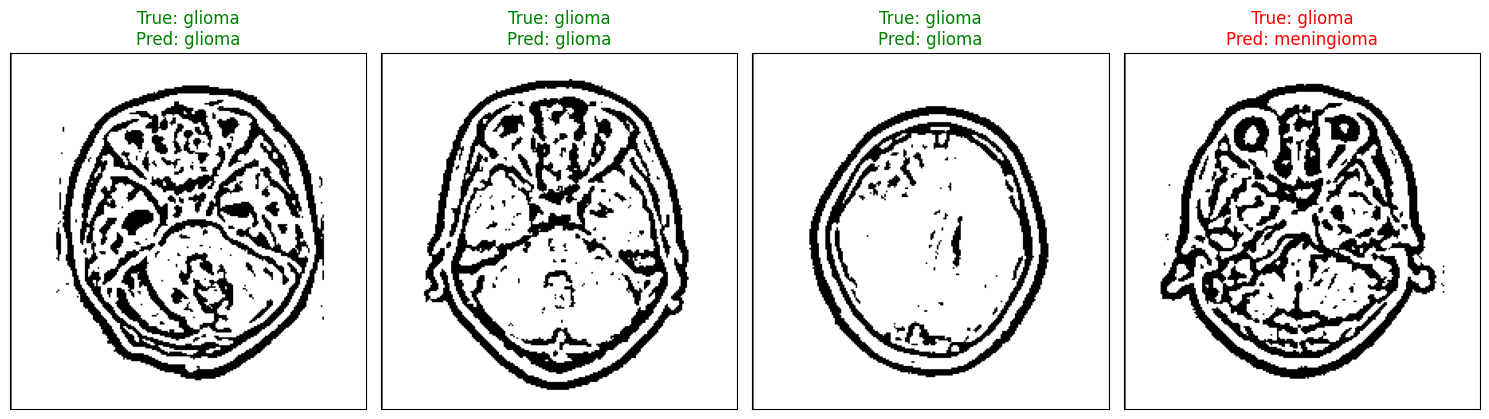

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the ResNet18 model is in evaluation mode
resnet_model.eval()

# Get a batch of test images and labels
dataiter = iter(test_loader)
images_res, labels_res = next(dataiter)

# Move images to the same device as the model
images_res = images_res.to(device)
labels_res = labels_res.to(device)

# Get predictions from the ResNet18 model
with torch.no_grad():
    outputs_res = resnet_model(images_res)

# Get predicted class labels
_, predicted_res = torch.max(outputs_res.data, 1)

# Function to unnormalize and display an image (reusing the previous imshow function)
def imshow_res(img):
    # Unnormalize image (reverse ImageNet normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy().transpose((1, 2, 0)) # Convert from tensor (C, H, W) to numpy (H, W, C)
    img = std * img + mean # Unnormalize
    img = np.clip(img, 0, 1) # Clip values to [0, 1]
    plt.imshow(img)

# Display images with true and predicted labels
fig = plt.figure(figsize=(15, 8))
for idx in np.arange(4):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    imshow_res(images_res[idx])
    true_label_res = train_dataset.classes[labels_res[idx]] # Use train_dataset.classes for label mapping
    pred_label_res = train_dataset.classes[predicted_res[idx]]
    ax.set_title(f"True: {true_label_res}\nPred: {pred_label_res}",
                 color=("green" if pred_label_res == true_label_res else "red"))

plt.tight_layout()
plt.show()

### Visualize Misclassified ResNet18 Images

Found 2 misclassified images in the last batch. Displaying up to 4:


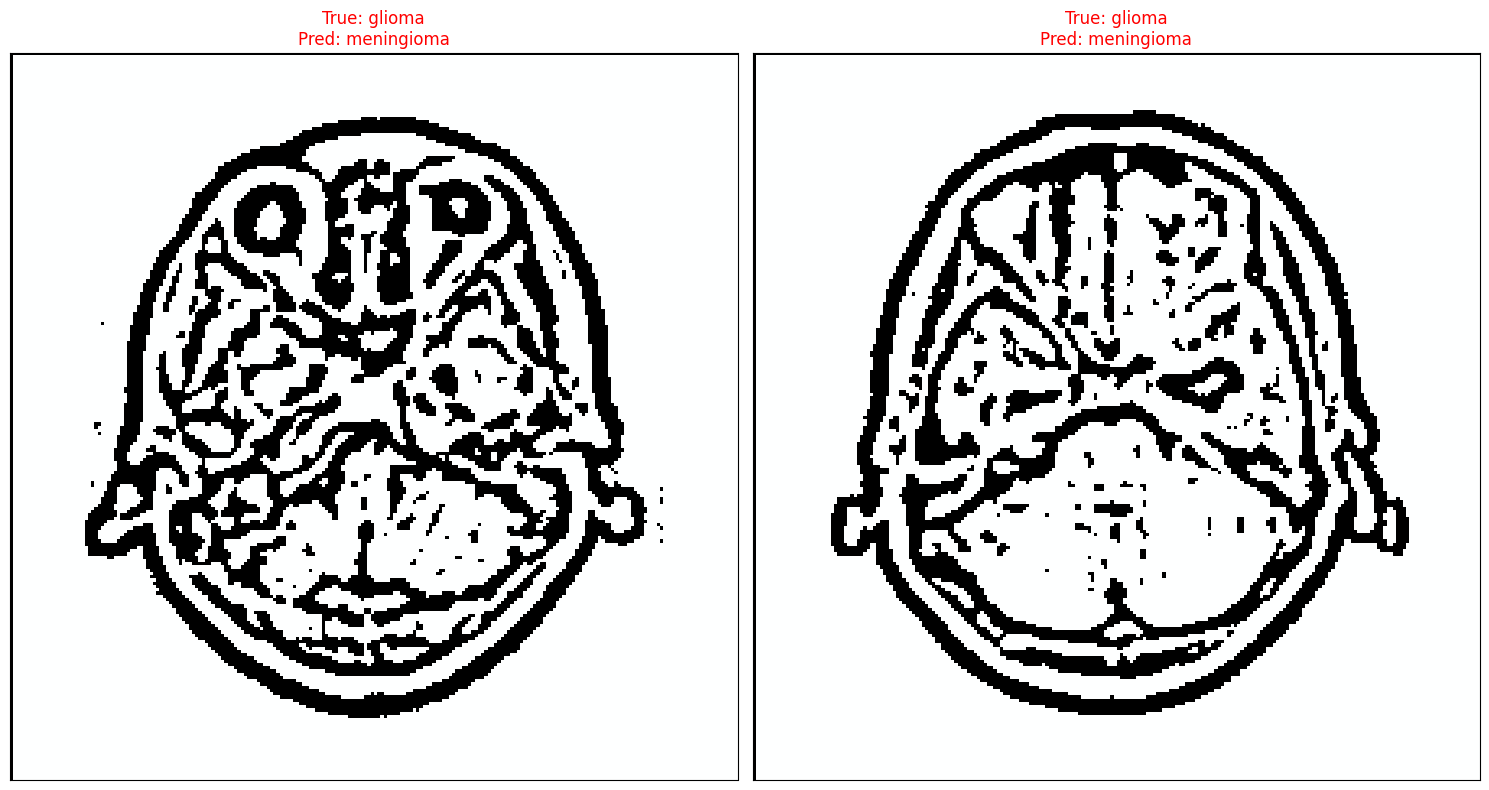

In [ ]:
misclassified_indices = (last_predicted_batch != last_labels_batch).nonzero(as_tuple=True)[0]

if len(misclassified_indices) == 0:
    print("No misclassified images found in the last batch.")
else:
    print(f"Found {len(misclassified_indices)} misclassified images in the last batch. Displaying up to 4:")
    fig = plt.figure(figsize=(15, 8))
    for i, idx in enumerate(misclassified_indices[:4]): # Display up to 4 misclassified images
        ax = fig.add_subplot(1, min(len(misclassified_indices), 4), i+1, xticks=[], yticks=[])
        imshow_res(last_images_batch[idx])
        true_label_res = train_dataset.classes[last_labels_batch[idx]]
        pred_label_res = train_dataset.classes[last_predicted_batch[idx]]
        ax.set_title(f"True: {true_label_res}\nPred: {pred_label_res}", color="red")
    plt.tight_layout()
    plt.show()

In [ ]:
num_epochs = 500  # Increased epochs for early stopping to potentially run longer

# Early Stopping parameters
patience = 15  # Number of epochs to wait if no improvement in test loss
min_delta = 0.00001 # Minimum change to be considered an improvement
best_test_loss = float('inf')
counter = 0 # Counter for epochs without improvement
best_model_state = None # To save the best model weights

# Lists to store loss and accuracy for plotting
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Training loop
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the parameter gradients

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagation
        optimizer.step() # Update model parameters

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)
    print(f"Epoch {epoch+1}, Training Loss: {epoch_train_loss:.4f}, Training Accuracy: {epoch_train_accuracy:.2f}%")

    # Evaluation loop
    model.eval() # Set the model to evaluation mode
    test_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad(): # Disable gradient calculation for evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    current_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct_test / total_test
    test_losses.append(current_test_loss)
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1}, Test Loss: {current_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    # Early stopping check
    if current_test_loss < best_test_loss - min_delta:
        best_test_loss = current_test_loss
        counter = 0  # Reset counter
        best_model_state = model.state_dict() # Save best model state
        print(f"  Test loss improved. Saving model.")
    else:
        counter += 1
        print(f"  Test loss did not improve. Counter: {counter}/{patience}")
        if counter >= patience:
            print(f"  Early stopping triggered after {epoch+1} epochs.")
            break

print("Finished Training")

# Load the best model weights if early stopping occurred
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model weights.")

Epoch 1, Training Loss: 0.7696, Training Accuracy: 69.62%
Epoch 1, Test Loss: 1.6223, Test Accuracy: 51.62%
  Test loss improved. Saving model.
Epoch 2, Training Loss: 0.7741, Training Accuracy: 69.52%
Epoch 2, Test Loss: 1.0271, Test Accuracy: 57.67%
  Test loss improved. Saving model.
Epoch 3, Training Loss: 0.7316, Training Accuracy: 70.36%
Epoch 3, Test Loss: 2.7940, Test Accuracy: 38.79%
  Test loss did not improve. Counter: 1/15
Epoch 4, Training Loss: 0.7377, Training Accuracy: 70.98%
Epoch 4, Test Loss: 1.2778, Test Accuracy: 55.90%
  Test loss did not improve. Counter: 2/15
Epoch 5, Training Loss: 0.7263, Training Accuracy: 71.50%
Epoch 5, Test Loss: 0.8434, Test Accuracy: 67.85%
  Test loss improved. Saving model.
Epoch 6, Training Loss: 0.7467, Training Accuracy: 70.54%
Epoch 6, Test Loss: 1.1748, Test Accuracy: 58.85%
  Test loss did not improve. Counter: 1/15
Epoch 7, Training Loss: 0.7630, Training Accuracy: 69.34%
Epoch 7, Test Loss: 1.3888, Test Accuracy: 54.72%
  Test 

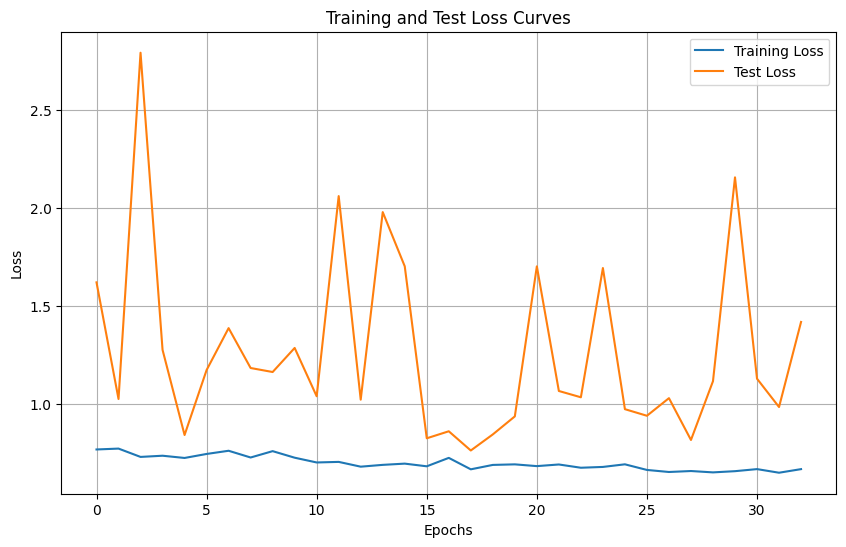

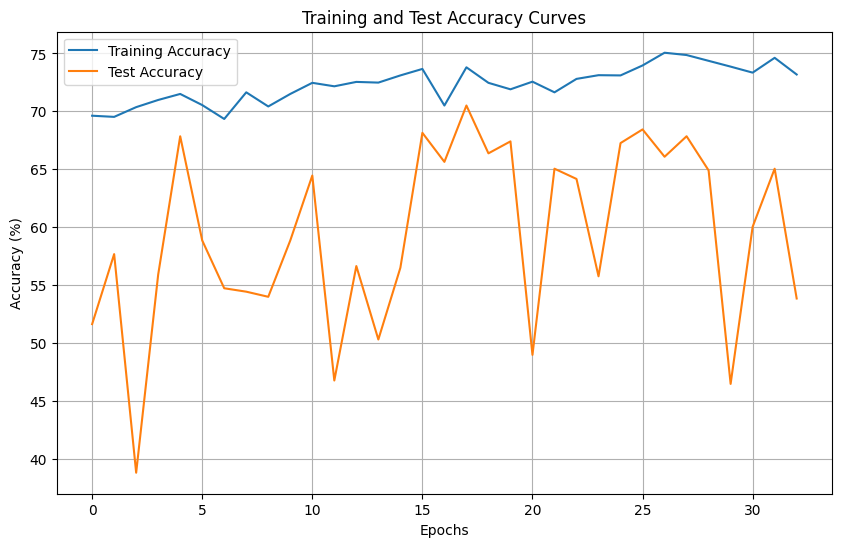

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and test loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

# Plotting training and test accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Test Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch

# Define the path to save the model
model_save_path = "simple_cnn_model.pth"

# Save the model's state dictionary
torch.save(model.state_dict(), model_save_path)

print(f"Model saved to {model_save_path}")

Model saved to simple_cnn_model.pth


### Load Saved Model for Evaluation

Now, let's load the saved model and prepare it for evaluation. We need to re-instantiate the model architecture and then load the saved state dictionary.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Re-define the SimpleCNN class (or ensure it's already defined and accessible)
# This is necessary to load the state_dict correctly.
# Assuming SimpleCNN class is already defined in a previous cell (6ca17353)

# Instantiate the model with the correct number of classes
# num_classes is available from the training setup
loaded_model = SimpleCNN(num_classes=num_classes)

# Load the saved state dictionary
model_save_path = "simple_cnn_model.pth"
loaded_model.load_state_dict(torch.load(model_save_path, map_location=device))

# Move the loaded model to the same device used during training
loaded_model.to(device)

# Set the model to evaluation mode
loaded_model.eval()

print(f"Model loaded successfully from {model_save_path} and set to evaluation mode on {device}.")

Model loaded successfully from simple_cnn_model.pth and set to evaluation mode on mps.


### Visualize Model Predictions on Test Images

Let's visualize the model's predictions on a sample batch of images from the test set to see how it performs.

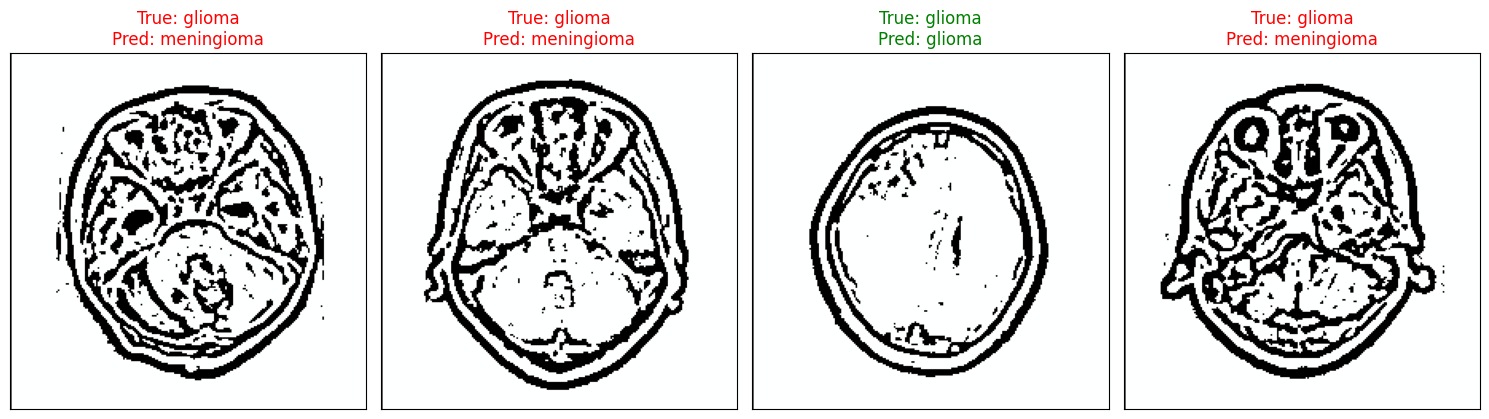

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test images and labels
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Move images to the same device as the model
images = images.to(device)
labels = labels.to(device)

# Get predictions from the loaded model
with torch.no_grad():
    outputs = loaded_model(images)

# Get predicted class labels
_, predicted = torch.max(outputs.data, 1)

# Function to unnormalize and display an image
def imshow(img):
    # Unnormalize image (reverse ImageNet normalization)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy().transpose((1, 2, 0)) # Convert from tensor (C, H, W) to numpy (H, W, C)
    img = std * img + mean # Unnormalize
    img = np.clip(img, 0, 1) # Clip values to [0, 1]
    plt.imshow(img)

# Display images with true and predicted labels
fig = plt.figure(figsize=(15, 8))
for idx in np.arange(4):
    ax = fig.add_subplot(2, 4, idx+1, xticks=[], yticks=[])
    imshow(images[idx])
    true_label = train_dataset.classes[labels[idx]] # Use train_dataset.classes for label mapping
    pred_label = train_dataset.classes[predicted[idx]]
    ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                 color=("green" if pred_label == true_label else "red"))

plt.tight_layout()
plt.show()

### Evaluate Model Performance Across All Classes

To get a comprehensive understanding of the model's performance, let's evaluate its accuracy across the entire test set. We'll also generate a classification report and a confusion matrix to visualize per-class performance, precision, recall, and F1-score.

Overall Test Accuracy: 47.05%

Classification Report:
              precision    recall  f1-score   support

      glioma       0.85      0.47      0.61       194
  meningioma       0.31      0.96      0.47       159
    no_tumor       0.89      0.18      0.30       139
   pituitary       0.85      0.27      0.41       186

    accuracy                           0.47       678
   macro avg       0.73      0.47      0.45       678
weighted avg       0.73      0.47      0.46       678



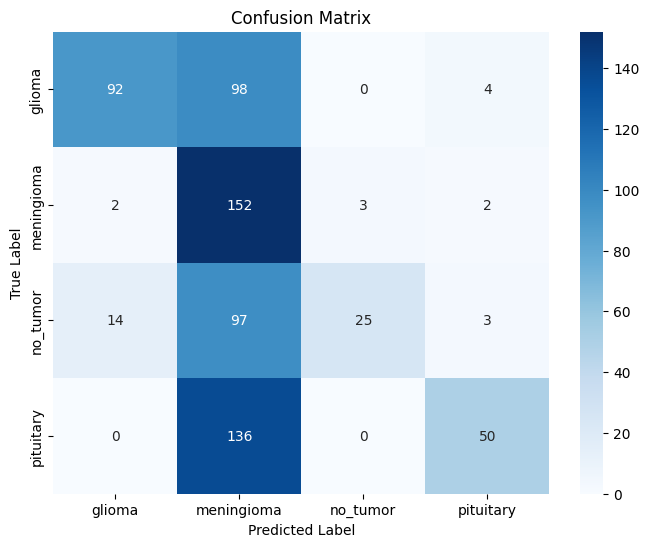

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure the model is in evaluation mode
loaded_model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = loaded_model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate overall accuracy
overall_correct = (torch.tensor(all_predictions) == torch.tensor(all_labels)).sum().item()
overall_total = len(all_labels)
overall_accuracy = 100 * overall_correct / overall_total

print(f"Overall Test Accuracy: {overall_accuracy:.2f}%")

# Generate classification report
class_names = train_dataset.classes
print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=class_names))

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np

def check_image_stats(paths):
    means = []
    for path in paths[:200]:  # sample 200
        try:
            img = Image.open(path).convert("RGB")
            arr = np.array(img)
            means.append(arr.mean())
        except:
            pass
    return np.mean(means), np.std(means)

train_mean, train_std = check_image_stats(train_image_paths)
test_mean, test_std = check_image_stats(test_image_paths)

print("Train mean/std:", train_mean, train_std)
print("Test mean/std:", test_mean, test_std)


Train mean/std: 48.633487002090476 7.954651387382558
Test mean/std: 47.81298852920532 8.237475868692718


In [ ]:
print(train_image_paths[:20])


['/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04308_pi_co_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04485_pi_sa_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04871_pi_sa_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04824_pi_sa_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_03590_pi_ax_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_03964_pi_ax_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_03931_pi_ax_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04479_pi_co_t1.jpg', '/Users/swaroopnaik1905/brisc2025/classification_task/train/pituitary/brisc2025_train_04280_pi_co_t1.jpg', '/Users/swaroopnaik1905/brisc2025/cl